# Classificar o intervalo das 11h00 às 12h00 como: vela de alta, vela lateral, vela de baixa.

Os horários das 9h, 10h e 11h são os horários de maior volatilidade e volume. Usar os dados OHLCV (preço de abertura e fechamento, preço máximo e mínimo, e volume) que compões uma vela de 5 minutos, do intervaldo das 9h às 10:55h para treinar uma rna com a finalidade de identificar três padrões (venda, compra, lateralidade) para o intervalo das 11h às 11:55h.

1. Abertura do Mercado (9:00 - 10:00)
Este é o momento mais volátil do dia. O preço de abertura é formado no leilão (08:45-9:00) e, quando a negociação começa às 9:00, o mercado absorve todas as notícias e expectativas acumuladas desde o fechamento do dia anterior. Há uma "briga" intensa entre compradores e vendedores para definir a direção inicial do dia.
Características:
* Movimentos de preço (spreads) muito amplos e rápidos.
* Volume de negociação altíssimo.

2. Abertura do Mercado Americano (11:30 - 12:30)
Por quê? O mercado brasileiro tem uma forte correlação com o mercado americano (índice S&P 500). Quando a bolsa de Nova York abre às 11:30 (horário de Brasília), há uma nova injeção de volume e volatilidade no nosso mercado. A direção que o mercado americano toma na sua primeira hora costuma influenciar fortemente o Ibovespa e, consequentemente, o mini-índice.
Características:
* Aumento súbito de volume e volatilidade.
* O mercado brasileiro pode reverter ou acelerar a tendência que vinha seguindo.
* Muitos traders aguardam essa abertura para confirmar suas posições.

O objetivo é executar uma ordem às 11h e encerrar essa ordem às 12h.

## Teste 1: Mapeamento Direto Vela-Neurônio
Testar uma rna em que os dados da primeira vela alimentão o **primeiro neurônio da camada oculta**. Os dados da segunda vela alimentão o **segundo neurônio da camada oculta**, assim por diante, os dados da ultima vela alimentão o ultimo neurônio da camada oculta.

*   **Arquitetura:**
    *   Dados da Vela 1 -> Neurônio 1 da camada oculta.
    *   Dados da Vela 2 -> Neurônio 2 da camada oculta.
    *   ...
    *   Dados da Vela 12 -> Neurônio 12 da camada oculta.
*   **Conceito:** Esta arquitetura força cada neurônio da camada oculta a se **especializar em uma única vela (um ponto específico no tempo)**. O Neurônio 1 aprenderá a extrair características apenas do que aconteceu entre 10:00 e 10:10. O Neurônio 2, do que aconteceu entre 10:10 e 10:20, e assim por diante.
*   **Vantagens:**
    *   **Interpretabilidade (relativa):** É mais fácil intuir o que cada neurônio está "olhando". Você pode analisar os pesos e ver qual das 12 velas teve mais impacto na decisão final.
    *   **Simplicidade Estrutural:** A conexão é esparsa e direta.
*   **Desvantagens/Desafios:**
    *   **Perda de Relações Cruzadas:** O modelo terá muita dificuldade em aprender padrões que envolvem a **interação entre diferentes velas**. Por exemplo, se um padrão de reversão depende da Vela 3 *e* da Vela 8, essa rede não consegue capturar essa relação na camada oculta, pois nenhum neurônio "vê" as duas velas ao mesmo tempo. A combinação das informações só ocorre na camada de saída.
    *   **Rigidez:** O modelo assume que a posição da vela no tempo é a característica mais importante. Ele não consegue identificar um mesmo padrão (ex: um engolfo de alta) se ele ocorrer às 10:30 ou às 11:10, pois seriam neurônios diferentes processando a informação.

## Teste 2: Arquitetura Totalmente Conectada (Dense)
Testar uma rna em que os dados da primeira vela **alimente todos os neurônios da camada oculta**, da segunda vela também alimente todos os neurônios da camada oculta, da terceira vela também, e assim por diante até a última vela.

*   **Arquitetura:**
    *   Cada feature de entrada é conectada a **todos os neurônios** da camada oculta.
*   **Conceito:** Esta é a arquitetura padrão de uma camada densa (ou *Fully Connected Layer*). Cada neurônio da camada oculta tem a capacidade de "olhar" para **todas as features de entrada simultaneamente**. Ele pode aprender a dar pesos diferentes para cada uma e, assim, identificar padrões complexos que envolvem a combinação de múltiplos dados de múltiplas velas.
*   **Vantagens:**
    *   **Capacidade de Aprender Relações Complexas:** É a principal vantagem. Um neurônio pode aprender a ativar se "o volume da Vela 2 for alto E o preço de fechamento da Vela 5 romper o máximo da Vela 4". Ele pode encontrar correlações entre qualquer ponto do intervalo de 2 horas.
    *   **Flexibilidade:** É a abordagem mais comum e poderosa para dados tabulares ou vetoriais, pois não impõe restrições sobre como as features devem interagir.
*   **Desvantagens/Desafios:**
    *   **Maior Risco de Overfitting:** Com mais conexões (mais parâmetros/pesos), o modelo tem mais "liberdade" para simplesmente memorizar os dados de treino em vez de aprender padrões generalizáveis. É crucial usar técnicas de regularização (como Dropout, L1/L2).
    *   **Menos Interpretabilidade:** É mais difícil entender exatamente qual combinação de features levou a uma determinada decisão, pois todos os neurônios veem tudo.

## Qual Abordagem é Melhor?
Para o seu problema, a Arquitetura 2 (Totalmente Conectada) é teoricamente muito superior e tem uma probabilidade de sucesso drasticamente maior.
Motivo: Padrões de mercado raramente dependem de uma única vela de 10 minutos isolada. Eles são, por natureza, uma sequência de eventos. Um padrão de compra pode ser uma queda seguida por uma vela de reversão com alto volume. A Arquitetura 1 teria dificuldade em "conectar" esses dois eventos, enquanto a Arquitetura 2 foi projetada exatamente para isso.

## Etapas para o Projeto

1.  **Pré-processamento de Dados:** 
    *   **Normalização/Padronização:** É fundamental para redes neurais. Usar `MinMaxScaler` ou `StandardScaler` em todos os seus dados de entrada (Abertura, Fechamento, Máximo, Mínimo, Volume).
    *   **Criação de Features (Feature Engineering):** Em vez de usar apenas os dados brutos (OHLCV), podemos criar features mais inteligentes, como:
        *   Tamanho do corpo da vela (`abs(fechamento - abertura)`).
        *   Tamanho da sombra superior (`máximo - max(abertura, fechamento)`).
        *   Médias móveis, RSI, MACD calculados sobre as velas de 10 minutos.

2.  **Arquitetura da Rede (Sugestão para o Teste 2):**
    *   **Camada de Entrada:** vai depender da quantidade de features de cada vela.
    *   **Camada(s) Oculta(s):** Começar com uma ou duas camadas densas. Um bom ponto de partida seria 64 neurônios na primeira e talvez 32 na segunda. Use a função de ativação `ReLU`.
    *   **Dropout:** Adicione camadas de Dropout (ex: `Dropout(0.3)`) após as camadas ocultas para combater o overfitting.
    *   **Camada de Saída:** 3 neurônios (um para cada classe: Compra, Venda, Lateral) com a função de ativação **`softmax`**, ideal para classificação multiclasse.
    *   **Otimizador e Perda:** Use o otimizador `Adam` e a função de perda `categorical_crossentropy`.

3.  **Validação:** Dividir os dados históricos em três conjuntos: **Treino, Validação e Teste**. Treine no primeiro, ajuste os hiperparâmetros (nº de neurônios, taxa de aprendizado, etc.) com base no desempenho do segundo e, no final, avalie o desempenho final no terceiro, que o modelo nunca viu.
 
## Exemplo

Imagine um padrão de compra clássico que se desenrola ao longo de 30 minutos:

1.  **Vela 3 (10:20-10:30):** Uma forte vela de queda, indicando pressão vendedora.
2.  **Vela 4 (10:30-10:40):** Uma vela de indecisão (um doji), com baixo volume.
3.  **Vela 5 (10:40-10:50):** Uma forte vela de alta (engolfo), com volume crescente, que "anula" a queda da Vela 3.

Este é um padrão de reversão de alta. A **condição para a compra** não está em nenhuma vela isolada, mas na **combinação sequencial** das três.

### Como Cada Arquitetura "Vê" Esse Padrão

#### Arquitetura 1 (Mapeamento Direto Vela-Neurônio)

*   **Neurônio 3** recebe os dados da Vela 3 (queda forte). Ele aprende a reconhecer "queda forte".
*   **Neurônio 4** recebe os dados da Vela 4 (doji). Ele aprende a reconhecer "indecisão".
*   **Neurônio 5** recebe os dados da Vela 5 (alta forte). Ele aprende a reconhecer "alta forte".

Até aqui, tudo bem. O problema é que **nenhum neurônio individual na camada oculta sabe que esses três eventos ocorreram em sequência**. O Neurônio 3 não sabe o que o Neurônio 5 está vendo. A única camada que recebe os sinais de todos eles ao mesmo tempo é a **camada de saída**.

Isso significa que a camada de saída (que geralmente é uma camada linear simples, com uma função softmax) tem a tarefa extremamente complexa de deduzir: "Ah, o Neurônio 3 ativou (queda), o Neurônio 4 ativou fracamente (indecisão) e o Neurônio 5 ativou fortemente (alta)... então, isso significa COMPRA".

É uma tarefa muito difícil para a camada final, pois a "inteligência" da extração de padrões complexos deveria ocorrer nas camadas ocultas. A rede perde a capacidade de criar uma "característica abstrata" que signifique "padrão de reversão de 3 velas".

#### Arquitetura 2 (Totalmente Conectada)

Nesta arquitetura, a situação é completamente diferente:

*   Um único neurônio na camada oculta (vamos chamá-lo de **Neurônio A**) recebe os dados de **TODAS** as velas (Vela 1 a 12).
*   Durante o treinamento, o **Neurônio A** pode aprender a ajustar seus pesos para se especializar em detectar exatamente o nosso padrão. Ele pode aprender a dar:
    *   **Peso alto** para as características da Vela 3 que indicam "queda forte".
    *   **Peso alto** para as características da Vela 4 que indicam "indecisão".
    *   **Peso altíssimo** para as características da Vela 5 que indicam "alta forte com volume".
    *   **Peso baixo ou zero** para todas as outras velas (1, 2, 6, 7, 8...).

Assim, o **Neurônio A** se torna um **"detector de padrão de reversão de 3 velas"**. Quando esse padrão ocorre, ele ativa fortemente e envia um sinal claro para a camada de saída que diz: "Eu encontrei um padrão de compra!". A tarefa da camada de saída fica muito mais fácil.

#### Conclusão
O ponto crucial é que a **Arquitetura 1 força cada neurônio oculto a ser míope**, vendo apenas um instante de 10 minutos. Ela delega a tarefa de conectar os pontos no tempo para a camada final, que é pouco preparada para isso.

A **Arquitetura 2 permite que os neurônios ocultos tenham uma visão panorâmica**, permitindo que eles se tornem detectores de padrões sofisticados que se desenrolam ao longo do tempo. É por isso que ela é conceitualmente mais poderosa para este tipo de problema.

## Incluir mais camadas ocultas no meu modelo do teste 1, faz com que os neurônios ocultos tenham uma visão panorâmica, assim como no teste2?
**Não, infelizmente não resolve o problema fundamental da Arquitetura 1.** Adicionar mais camadas ocultas não permitirá que ela aprenda as mesmas relações complexas que a Arquitetura 2 (Totalmente Conectada) aprende.

A resposta longa explica o porquê, e isso nos leva a um conceito central em arquitetura de redes neurais: o **fluxo de informação** e o **campo receptivo** dos neurônios.

### O Problema: O Fluxo de Informação Restrito

Vamos visualizar o fluxo de informação na sua Arquitetura 1, mesmo com camadas ocultas adicionais.

**Arquitetura 1 com Uma Camada Oculta (Original):**

*   **Entrada:**
    *   Dados da Vela 1 (x1-x5)
    *   Dados da Vela 2 (x6-x10)
    *   ...
*   **Camada Oculta 1:**
    *   Neurônio Oculto 1.1 (só vê a Vela 1)
    *   Neurônio Oculto 1.2 (só vê a Vela 2)
    *   ...
*   **Camada de Saída:**
    *   Recebe sinais de todos os neurônios da Camada Oculta 1. **É o primeiro e único lugar onde a informação de diferentes velas se encontra.**

**Arquitetura 1 com Duas Camadas Ocultas (Sua Pergunta):**

Agora, vamos adicionar uma segunda camada oculta. Como as conexões seriam? A maneira mais natural de estender a Arquitetura 1 seria uma conexão totalmente conectada entre as camadas ocultas.

*   **Entrada:**
    *   Dados da Vela 1 (x1-x5)
    *   Dados da Vela 2 (x6-x10)
    *   ...
*   **Camada Oculta 1:**
    *   Neurônio Oculto 1.1 (só vê a Vela 1)
    *   Neurônio Oculto 1.2 (só vê a Vela 2)
    *   ...
*   **Camada Oculta 2:**
    *   Cada neurônio aqui (vamos chamar de Neurônio Oculto 2.1) recebe sinais de **todos** os neurônios da Camada Oculta 1.
*   **Camada de Saída:**
    *   Recebe sinais de todos os neurônios da Camada Oculta 2.

### A Falha Crítica na Lógica

À primeira vista, parece que o problema foi resolvido! O Neurônio Oculto 2.1 agora "vê" a informação de todas as velas, certo?

**Sim, mas de uma forma extremamente limitada e pré-processada.**

O Neurônio Oculto 2.1 não vê os dados brutos da Vela 1 e da Vela 2. Ele vê:
*   A **interpretação** que o Neurônio Oculto 1.1 fez da Vela 1.
*   A **interpretação** que o Neurônio Oculto 1.2 fez da Vela 2.
*   E assim por diante.

Cada neurônio da primeira camada oculta age como um **filtro isolado**. Ele processa sua própria vela e passa adiante uma única informação resumida (sua ativação). Ele já descartou a maior parte dos detalhes brutos (a relação entre Abertura e Máxima daquela vela específica, por exemplo).

A segunda camada oculta recebe apenas esses resumos. Ela não tem mais acesso aos dados originais para encontrar correlações cruzadas. É como o jogo do "telefone sem fio":

1.  **Arquitetura 2 (Totalmente Conectada):** Um detetive (neurônio oculto) tem acesso a **todas as fotos da cena do crime** (todas as 60 features) e pode procurar por pistas que conectam uma foto à outra.

2.  **Arquitetura 1 com Camadas Extras:** Existem 12 detetives juniores. Cada um olha para **uma única foto** e escreve um resumo de uma linha sobre ela. Depois, um detetive sênior (neurônio da segunda camada) lê apenas os **12 resumos** para tentar solucionar o crime. Ele perdeu toda a riqueza de detalhes das fotos originais. Ele não pode mais verificar se a sombra na Foto 3 corresponde ao objeto na Foto 8.

### Conclusão: Por que a Arquitetura 2 é Superior

A **Arquitetura 2 (Totalmente Conectada)** dá a cada neurônio da primeira camada oculta acesso total e irrestrito a **as features de todas as velas**.

Isso permite que um único neurônio aprenda a função:
`ativar = f(Volume_Vela2, Fechamento_Vela5, Máxima_Vela9, ...)`

Ele pode criar um "detector de padrões" que correlaciona diretamente qualquer detalhe bruto de qualquer vela com qualquer outro detalhe bruto de qualquer outra vela.

A **Arquitetura 1**, mesmo com mais camadas, força uma hierarquia de processamento que destrói essa capacidade. A primeira camada cria resumos isolados, e as camadas subsequentes só podem trabalhar com esses resumos, nunca com os dados originais combinados.

Portanto, para atingir seu objetivo de "identificar padrões complexos que envolvem a combinação de múltiplos dados de múltiplas velas", você precisa de uma arquitetura onde os neurônios tenham um **campo receptivo** amplo desde o início, como na Arquitetura 2 ou em Redes Neurais Convolucionais (CNNs) e Recorrentes (RNNs), que são ainda mais especializadas nisso.


## Outras alternativas
Excelente pergunta! Sua abordagem atual é um ótimo ponto de partida, pois é bem definida e testável. No entanto, o mercado é dinâmico, e explorar outras estratégias pode revelar abordagens mais robustas ou lucrativas.

Aqui estão algumas alternativas, organizadas por tipo de mudança, que você pode considerar para o seu projeto.

---

### Alternativa 1: Mudar o Foco do "O Quê" para o "Quando" (Modelos de Timing)

Em vez de prever a direção de um período fixo, o objetivo aqui é identificar o **momento exato** de uma oportunidade de trade, com um alvo e stop definidos.

*   **Estratégia: Previsão de Eventos de Curto Prazo**
    *   **Objetivo do Modelo:** Em vez de prever "Compra/Venda/Lateral para a próxima hora", o modelo prevê: "A probabilidade de o preço subir `X` pontos antes de cair `Y` pontos nos próximos `N` minutos é de `Z%`?".
    *   **Como Funciona:**
        1.  **Janela Deslizante:** A cada nova vela de 10 minutos (ou até 1 minuto), o modelo analisa a janela de dados mais recente (ex: as últimas 10 velas).
        2.  **Saída do Modelo:** A RNA produz uma probabilidade para um evento, como "Cruzamento de Média Móvel", "Rompimento de Máxima/Mínima" ou "Reversão de RSI".
        3.  **Execução:** Se a probabilidade prevista para um evento de "compra" ultrapassar um limiar (ex: 75%), o robô executa a ordem imediatamente.
        4.  **Gerenciamento de Risco:** A ordem já entra com um **alvo (take profit)** e um **stop loss** pré-definidos (ex: alvo de 200 pontos, stop de 100 pontos). A operação é encerrada quando um dos dois é atingido, não por um horário fixo.
    *   **Vantagens:** Mais dinâmico, captura oportunidades a qualquer momento do dia e possui um gerenciamento de risco mais claro e integrado à operação.

---

### Alternativa 2: Mudar a Arquitetura para Capturar a "Memória" do Mercado

Sua abordagem atual usa uma janela fixa. Redes Neurais Recorrentes (RNNs), especialmente LSTMs, são projetadas para entender sequências de comprimento variável e manter uma "memória" de longo prazo.

*   **Estratégia: Modelo Preditivo com LSTM (Long Short-Term Memory)**
    *   **Objetivo do Modelo:** Prever o preço (ou a direção) da **próxima vela** com base em uma sequência de velas anteriores.
    *   **Como Funciona:**
        1.  **Treinamento:** Você treina uma LSTM para, dada uma sequência de (por exemplo) 20 velas, prever as características da 21ª vela.
        2.  **Execução:** A cada 10 minutos, o robô alimenta a sequência mais recente de velas na LSTM.
        3.  **Decisão:** Se o modelo prevê que a próxima vela terá um fechamento significativamente mais alto (ex: `> 0.2%`), ele inicia uma compra. Se prevê uma queda, inicia uma venda.
        4.  **Encerramento:** A posição pode ser encerrada no final da própria vela de 10 minutos, ou mantida enquanto as previsões subsequentes continuarem a confirmar a tendência.
    *   **Vantagens:** Arquitetura teoricamente mais adequada para séries temporais. O modelo aprende a dar pesos diferentes a eventos recentes vs. antigos de forma mais natural.

---

### Alternativa 3: Mudar o Foco do Preço para a Volatilidade

Em vez de prever a direção, que é extremamente difícil, você pode prever a **volatilidade**.

*   **Estratégia: Operar Rompimentos de Volatilidade (Breakouts)**
    *   **Objetivo do Modelo:** Prever se a próxima hora será de **alta volatilidade** (grandes movimentos) ou **baixa volatilidade** (mercado lateral).
    *   **Como Funciona:**
        1.  **Treinamento:** A RNA é treinada com dados das 10:00-12:00. O "gabarito" (label) não é "Compra/Venda", mas sim "Alta Volatilidade" ou "Baixa Volatilidade" para o período das 12:00-13:00. (Você pode definir "Alta Volatilidade" como um movimento de preço > `X` pontos, por exemplo).
        2.  **Execução:** Se o modelo prevê "Alta Volatilidade", o robô pode adotar uma estratégia de **rompimento**. Ele coloca uma ordem de compra um pouco acima da máxima do período 10-12h e uma ordem de venda um pouco abaixo da mínima. A primeira que for executada cancela a outra.
        3.  **Encerramento:** A posição é gerenciada com um alvo ou um stop móvel (trailing stop).
    *   **Vantagens:** Prever a volatilidade pode ser mais fácil do que prever a direção. Essa estratégia lucra com grandes movimentos, independentemente da direção.

---

### Alternativa 4: Mudar o Paradigma para Aprendizado por Reforço (Reinforcement Learning)

Esta é a abordagem mais avançada e complexa, mas também a que mais se assemelha a como um trader humano aprende.

*   **Estratégia: Agente de RL que Aprende a Operar**
    *   **Objetivo do Modelo:** O modelo (o "agente") não prevê o futuro. Ele aprende a tomar a **melhor ação** (Comprar, Vender, Manter/Ficar de Fora) em cada passo do tempo para maximizar uma recompensa futura (o lucro).
    *   **Como Funciona:**
        1.  **Ambiente:** Você cria um ambiente de simulação do pregão.
        2.  **Agente:** O agente observa o estado do mercado (preços, indicadores, etc.).
        3.  **Ação:** A cada vela, ele toma uma ação.
        4.  **Recompensa:** Se a ação levou a um lucro, ele recebe uma recompensa positiva. Se levou a um prejuízo, recebe uma recompensa negativa (punição).
        5.  **Aprendizado:** Ao longo de milhões de simulações, o agente aprende, por tentativa e erro, uma **política** (uma estratégia) que mapeia estados do mercado a ações que maximizam a recompensa acumulada.
    *   **Vantagens:** Potencialmente a abordagem mais poderosa, pois o modelo aprende uma estratégia completa de trading, incluindo quando entrar, quando sair e quando não fazer nada.
    *   **Desvantagens:** Extremamente complexo de implementar, treinar e validar. Requer muito mais dados e poder computacional.

### Tabela Comparativa de Alternativas

| Estratégia | Foco Principal | Vantagem Principal | Complexidade |
| :--- | :--- | :--- | :--- |
| **Sua Atual** | Prever direção de um período fixo | Bem definida, fácil de testar | Média |
| **Timing de Eventos** | Prever o "quando" de uma oportunidade | Dinâmica, gerenciamento de risco integrado | Média-Alta |
| **LSTM Preditiva** | Prever a próxima vela na sequência | Arquitetura ideal para séries temporais | Alta |
| **Previsão de Volatilidade** | Prever a magnitude do movimento | Não depende de acertar a direção | Média |
| **Aprendizado por Reforço** | Aprender uma política de ações ótima | A mais completa e adaptativa | Muito Alta |

**Minha recomendação:**
Comece com sua ideia original, pois ela é um excelente projeto de aprendizado. Depois de validá-la (ou invalidá-la), a **Alternativa 1 (Timing de Eventos)** é o próximo passo mais lógico e poderoso, pois introduz um gerenciamento de risco mais sofisticado e permite que o robô opere de forma mais flexível.

# Coletando dados do mini índice

## qual ticket de contrato contínuo usar?

Essa lista mostra as diferentes maneiras que a sua plataforma (MetaTrader) constrói a série histórica contínua, que une os diferentes vencimentos (WING26, WINJ26, etc.) em um único gráfico longo.

Vamos decifrar o que cada parte significa. Um ticker de contrato contínuo aqui é formado por: **ATIVO + CRITÉRIO + AJUSTE**.

### 1. Critério de Rolagem: Como a plataforma decide quando pular para o próximo contrato?

Existem duas formas principais de fazer a "rolagem" (a troca do contrato que está vencendo pelo próximo):

*   **Por Vencimento (símbolo `@`)**: A plataforma usa o contrato atual (ex: WING26) até a sua data de vencimento oficial. No dia do vencimento, ela troca para o próximo contrato (WINJ26).
    *   **Tickers na imagem:** `WIN@`, `WDO@`, `WIN@D`, `WIN@N`, `WDO@D`, `WDO@N`
    *   **Característica:** Reflete o comportamento "oficial" do mercado.

*   **Por Liquidez (símbolo `$`)**: Esta é a forma mais usada por traders. A plataforma não espera até o dia do vencimento. Ela troca para o próximo contrato alguns dias antes, quando a **liquidez** (o volume de negociações) do contrato seguinte se torna maior que a do contrato atual.
    *   **Tickers na imagem:** `WIN$`, `WDO$D`, `WDO$N`, `WIN$D`, `WIN$N`
    *   **Característica:** Reflete melhor o comportamento do "dinheiro de verdade" no mercado, pois os grandes players migram para o próximo contrato antes do vencimento. **Para backtesting, este critério é geralmente preferível.**

---

### 2. Método de Ajuste: Como a plataforma lida com o "gap" de preço na rolagem?

Quando a plataforma troca de um contrato para o outro, quase sempre há uma diferença de preço entre eles (ex: o WING26 fecha a 130.000 e o WINJ26 abre a 130.500). Esse "salto" artificial de 500 pontos não foi um movimento real do mercado, foi apenas uma junção de contratos. O método de ajuste corrige isso.

*   **Ajuste Proporcional (nenhuma letra extra ou `P` em algumas plataformas)**: Ele ajusta todo o histórico para trás de forma proporcional, para que não haja nenhum "salto" visível no gráfico.
    *   **Ticker na imagem:** `WIN$` (sozinho)
    *   **Característica:** Cria um gráfico visualmente contínuo e suave, ótimo para análise gráfica. No entanto, os preços históricos que você vê **não são os preços que foram realmente negociados** no passado.

*   **Ajuste por Diferença (letra `D`)**: Ele soma ou subtrai a diferença de preço da rolagem em todo o histórico para trás.
    *   **Tickers na imagem:** `WDO$D`, `WDO@D`, `WIN$D`, `WIN@D`
    *   **Característica:** O efeito é similar ao proporcional, mas o cálculo é diferente. Também altera os preços históricos.

*   **Sem Ajustes (letra `N` de "None")**: A plataforma simplesmente junta os contratos. O "salto" (gap) de preço na rolagem fica visível no gráfico.
    *   **Tickers na imagem:** `WDO$N`, `WDO@N`, `WIN$N`, `WIN@N`
    *   **Característica:** Os preços que você vê no gráfico são os **preços reais que foram negociados em cada dia no passado**. Para um modelo de Machine Learning, que precisa ser treinado com os valores mais fiéis possíveis à realidade, **esta é quase sempre a melhor opção.** O modelo aprenderá a lidar com os gaps de rolagem como parte do comportamento do mercado.

---

### Qual Usar no seu Código?

Com base na sua imagem e no seu objetivo de treinar uma RNA, a recomendação é clara. Você quer:
1.  **Rolagem por Liquidez (`$`)**: Para refletir o comportamento real do mercado.
2.  **Sem Ajustes (`N`)**: Para usar os preços históricos reais.

Portanto, o ticker ideal para você usar no seu script Python é:

**`WIN$N`**

Este ticker corresponde à linha: **IBOVESPA MINI - Por Liquidez (WING26) - Sem Ajustes**.

Ao usar `WIN$N`, você estará alimentando sua rede neural com os dados mais puros e representativos da realidade histórica do mercado, o que é fundamental para a qualidade do treinamento.

## Features vs. Labels 

Você deve usar **APENAS os candles das 11:00 às 11:55** para criar os labels.

Vamos detalhar o porquê, pois este conceito é a base de todo o seu projeto.

### A Separação Fundamental: Features vs. Labels

Pense no seu projeto como um processo de "causa e efeito" que você está ensinando à sua RNA:

1.  **A Causa (FEATURES):** São os dados de **entrada**. É a informação que a RNA terá disponível no momento de tomar a decisão. No seu caso, são os dados dos candles das **09:00 às 10:55**. Esta é a "pergunta" que você faz ao modelo: "Olhando para o que aconteceu nesta janela, o que você acha que vai acontecer a seguir?"

2.  **O Efeito (LABELS):** São os dados de **saída** ou o **alvo**. É a "resposta correta" que você quer que a RNA aprenda a prever. No seu caso, é o que de fato aconteceu no futuro, ou seja, o comportamento do mercado das **11:00 às 11:55**.

### Por que a Separação é Crucial? (O Perigo do "Data Leakage")

Se você usasse qualquer informação da janela das 09:00-10:55 para criar o seu label, você estaria cometendo o erro mais grave em Machine Learning: **Data Leakage (Vazamento de Dados)**.

**Analogia do Vazamento de Dados:**

Imagine que você quer treinar uma RNA para prever o resultado de um jogo de futebol (Vitória, Derrota, Empate) usando as estatísticas do primeiro tempo (chutes a gol, posse de bola, etc.).

*   **Features (Causa):** Estatísticas do 1º tempo.
*   **Label (Efeito):** Resultado final do jogo.

Agora, imagine que, ao criar o label, você usa a seguinte regra: "Se o time da casa venceu E teve mais posse de bola no primeiro tempo, o label é 'Vitória Forte'".

O que acontece? Você "vazou" uma informação das features (posse de bola no 1º tempo) para dentro da definição da sua resposta. Durante o treinamento, a RNA vai perceber: "Ah, é fácil! Toda vez que a posse de bola no 1º tempo é alta, a resposta tende a ser 'Vitória Forte'".

O modelo parecerá ter uma performance incrível durante o treinamento e validação. Mas no mundo real, quando ele só tiver as estatísticas do 1º tempo e não souber o resultado final, ele não terá essa "dica" vazada e seu desempenho será péssimo.

### Aplicando ao Seu Caso

*   **Seu Input (Features):** Tudo o que aconteceu das 09:00 às 10:55. Isso inclui os preços, volumes, indicadores, etc., dessa janela.
*   **Seu Output (Labels):** Uma classificação (Compra, Venda, Lateral) que descreve **exclusivamente** o que aconteceu na janela futura, das 11:00 às 11:55.

**Exemplo Correto de Labeling:**

Para cada dia no seu histórico:
1.  Pegue os dados das 09:00-10:55. Este será seu `X` (dado de entrada).
2.  Olhe **APENAS** para os dados das 11:00-11:55.
3.  Com base **APENAS** nesta janela futura, aplique suas regras:
    *   O fechamento das 11:55 foi X pontos acima da abertura das 11:00?
    *   A mínima durante este período não violou um certo limite?
    *   Se sim, o label para o `X` daquele dia é **"Compra"**.
    *   ...e assim por diante para "Venda" e "Lateralidade".

Dessa forma, você garante que a RNA está aprendendo uma relação genuína de causa e efeito, sem nenhuma "dica" do futuro que ela não teria em uma situação de trading real.

## Features para a criação do labels
Criando algumas features para o intervalo das velas das 11h00 às 11h50. 

**Fase 1: Engenharia de Features para a Janela de Alvo (11:00 - 11:55)**

Para cada dia no seu histórico, você vai olhar **apenas para a janela das 11:00-11:55** e criar um conjunto de "features descritivas" que representem o que aconteceu nesse período. Essas features não são para o treinamento da RNA final, mas sim para a clusterização, no processo de label (super compra, compra, lateralidade, venda, super venda).

Boas features descritivas seriam:

1.  **`retorno_total`**: `(Fechamento_11:55 - Abertura_11:00) / Abertura_11:00`. Mede a direção e magnitude do movimento.
2.  **`volatilidade_total`**: `(Maxima_periodo - Minima_periodo) / Abertura_11:00`. Mede a volatilidade total.
3.  **`posicao_fechamento`**: `(Fechamento_11:55 - Minima_periodo) / (Maxima_periodo - Minima_periodo)`. Um valor perto de 1 significa que fechou na máxima; perto de 0, na mínima; perto de 0.5, no meio.
4.  **`drawdown_maximo`**: `(Abertura_11:00 - Minima_periodo) / Abertura_11:00`. Mede o "sofrimento" ou risco durante o período.
5.  **`runup_maximo`**: `(Maxima_periodo - Abertura_11:00) / Abertura_11:00`. Mede o potencial de lucro que foi atingido.
6.  **`volume_medio`**: O volume médio dos candles no período.

### Pontos positivos
Invariância ao Nível de Preço: Features como **retorno_total** e **range_normalizado** são relativas. Elas capturam a essência do movimento, independentemente do nível de preço absoluto. Uma alta de 0.5% é sempre uma alta de 0.5%.

### Drawdown e Run-up
Drawdown e Run-up são conceitos cruciais para medir o **risco** e a **oportunidade** de uma operação.

Vamos detalhar cada um com uma analogia simples.

Imagine que você entra em uma operação (compra ou venda) no início de um período (no seu caso, às 11:00). O preço de entrada é a sua "linha d'água".

#### 1. Drawdown (Rebaixamento)

O Drawdown mede o tamanho do pavio contra a sua posição, é o **máximo movimento *contra* a sua posição** durante um período. É a "pior dor" ou o "máximo sofrimento" que a operação te causou antes de (potencialmente) se recuperar. Ele mede o risco.

*   Em uma **operação de COMPRA** (você aposta na alta), o Drawdown é a distância entre o seu preço de entrada e a **MÍNIMA** do período. Esse movimento contra você é representado visualmente pelo **PAVIO INFERIOR** do candle (ou do conjunto de candles). Um pavio inferior longo significa um Drawdown grande.
    *   Em uma **operação de VENDA** (você aposta na baixa), o Drawdown é a distância entre o seu preço de entrada e a **MÁXIMA** do período. Esse movimento contra você é representado pelo **PAVIO SUPERIOR**.

#### 2. Run-up (Potencial de Lucro)
O Run-up mede o o **máximo movimento *a favor* da sua posição** durante um período. É o "lucro máximo" que a operação atingiu, mesmo que depois ela tenha recuado e você não tenha realizado todo esse lucro. Ele mede a oportunidade.

#### Por que isso é Tão Importante para o seu Modelo?

Ao criar features como `drawdown_maximo` e `runup_maximo` para a sua fase de clusterização, você está ensinando ao algoritmo a diferenciar a **qualidade** dos movimentos.

Considere dois dias diferentes, ambos com um resultado final de "Compra" (o preço fechou 200 pontos acima da abertura):

*   **Dia A (Movimento Limpo):**
    *   **Drawdown:** 20 pontos
    *   **Run-up:** 210 pontos
    *   **Interpretação:** Um movimento de compra forte, limpo e de baixo risco. O mercado mal voltou contra a posição. **Este é um "trade de alta qualidade".**

*   **Dia B (Movimento Volátil e Arriscado):**
    *   **Drawdown:** 300 pontos
    *   **Run-up:** 500 pontos
    *   **Interpretação:** O mercado primeiro caiu 300 pontos (o que teria stopado a maioria dos traders), para só depois subir e fechar 200 pontos no positivo. Embora o resultado final tenha sido positivo, o caminho foi extremamente arriscado. **Este é um "trade de baixa qualidade".**

Um modelo que só olha para o preço de abertura e fechamento consideraria os Dias A e B como "iguais". Um modelo que usa Drawdown e Run-up como features consegue diferenciá-los perfeitamente. Ele pode aprender a focar em prever apenas os movimentos de "alta qualidade" (Dia A) e classificar os movimentos de "baixa qualidade" (Dia B) como "Lateralidade" ou um tipo diferente de padrão, tornando suas previsões muito mais robustas e aplicáveis ao trading real.

### `volatilidade_total` (O Termômetro da Energia)

*   **Fórmula:** `(Maxima_do_periodo - Minima_do_periodo) / Abertura_11:00`
*   **O que mede:** O range total do movimento, ou seja, a "energia" ou a "agitação" do mercado durante aquela hora.

**Como Ajuda na Clusterização?**

A `volatilidade_total` permite separar os movimentos pela sua **magnitude**. Ela responde à pergunta: "Foi um dia agitado ou um dia calmo?"

Imagine dois dias, ambos com `retorno_total` próximo de zero.

*   **Dia A (Lateralidade de Baixa Volatilidade):**
    *   `retorno_total`: ~0%
    *   `volatilidade_total`: **Baixa** (ex: 0.2%)
    *   **Interpretação:** O mercado ficou "morto". Abriu, moveu-se muito pouco para cima e para baixo, e fechou perto da abertura. Foi um período de tédio e baixa liquidez.

*   **Dia B (Indecisão de Alta Volatilidade):**
    *   `retorno_total`: ~0%
    *   `volatilidade_total`: **Alta** (ex: 1.0%)
    *   **Interpretação:** O mercado foi um "campo de batalha". O preço subiu muito, depois caiu muito (ou vice-versa), e no final, por exaustão, fechou perto da abertura. Foi um período de briga intensa e indecisão.

Sem a `volatilidade_total`, o K-Means poderia agrupar os dias A e B no mesmo cluster de "Lateralidade". Com ela, ele os separará em dois clusters distintos:
*   **Cluster "Lateral Calmo":** Caracterizado por baixa volatilidade.
*   **Cluster "Lateral Agitado/Indeciso":** Caracterizado por alta volatilidade.

Isso é vital, pois a estratégia para operar após um dia "calmo" (esperar um rompimento) é diferente da estratégia após um dia "agitado" (esperar a poeira baixar).

### `posicao_fechamento` (O Indicador de Convicção Final)

*   **Fórmula:** `(Fechamento_11:55 - Minima_do_periodo) / (Maxima_do_periodo - Minima_do_periodo)`
*   **O que mede:** Onde o preço fechou em relação ao seu range total do período. É um valor entre 0.0 e 1.0.
    *   **Perto de 1.0:** Fechou na máxima. Convicção compradora total no final.
    *   **Perto de 0.0:** Fechou na mínima. Convicção vendedora total no final.
    *   **Perto de 0.5:** Fechou no meio do caminho. Indecisão no final.

**Como Ajuda na Clusterização?**

A `posicao_fechamento` qualifica a **força do final do movimento**. Ela responde à pergunta: "A força que moveu o preço durante o dia se manteve até o fim?"

Imagine dois dias, ambos com `retorno_total` positivo.

*   **Dia C (Compra com Convicção):**
    *   `retorno_total`: +0.5%
    *   `posicao_fechamento`: **0.95** (perto de 1.0)
    *   **Interpretação:** O mercado subiu e **fechou na máxima**. Os compradores estavam no controle total até o último segundo. Isso sugere uma alta probabilidade de continuação no dia seguinte.

*   **Dia D (Compra com Exaustão):**
    *   `retorno_total`: +0.5%
    *   `posicao_fechamento`: **0.60** (mais para o meio)
    *   **Interpretação:** O mercado subiu, atingiu uma máxima bem mais alta, mas depois os vendedores apareceram e empurraram o preço para baixo, fazendo-o fechar longe da máxima (deixando um pavio superior). Embora o dia tenha sido de alta, ele terminou com um sinal de fraqueza.

Sem a `posicao_fechamento`, os dias C e D poderiam cair no mesmo cluster de "Compra". Com ela, o K-Means os separará:
*   **Cluster "Compra Forte":** Caracterizado por `posicao_fechamento` alta.
*   **Cluster "Compra Fraca/Exausta":** Caracterizado por `posicao_fechamento` mais baixa.

### `volume_medio_normalizado`  (O Selo de Confirmação)
1. Primeiro, calcule uma média móvel longa do volume diário para ter uma noção do que é um volume "normal" em cada época. Por exemplo, uma média móvel de **20 dias** do volume total diário.
2. Depois, para cada dia, calcule o volume_medio da sua janela **(11:00-11:55)**.
3. Normalize o volume_medio da janela pela média móvel longa do volume.

**Fórmula**: volume_medio_normalizado = volume_medio_janela / media_movel_longa_volume:

* Valor > 1.0: O volume na sua janela foi maior que o normal daquela época.
* Valor < 1.0: O volume na sua janela foi menor que o normal.
* Valor ≈ 1.0: O volume foi normal.
  
**Como Ajuda na Clusterização?**

O `volume_medio` age como um **validador de importância**. Ele responde à pergunta: "Esse movimento que aconteceu foi relevante ou foi apenas ruído?"

Imagine dois dias, ambos com um `retorno_total` de +0.8% (uma alta forte).

*   **Dia E (Alta com Confirmação de Volume):**
    *   `retorno_total`: +0.8%
    *   `volume_medio`: **Alto** (acima da média geral)
    *   **Interpretação:** Uma alta forte que foi acompanhada por um grande número de negociações. Isso indica que grandes players (instituições) participaram e validaram o movimento. É um sinal de alta confiável.

*   **Dia F (Alta com Baixo Volume):**
    *   `retorno_total`: +0.8%
    *   `volume_medio`: **Baixo** (abaixo da média geral)
    *   **Interpretação:** Uma alta forte que ocorreu com pouca negociação. Isso pode acontecer em períodos de baixa liquidez (como perto de feriados). O movimento é suspeito e pode ser facilmente revertido quando a liquidez voltar. É um sinal de baixa confiabilidade.

Sem o `volume_medio`, os dias E e F seriam vistos como idênticos. Com ele, o K-Means os separará:
*   **Cluster "Tendência Institucional":** Movimentos direcionais com alto volume.
*   **Cluster "Movimento Vazio/Armadilha":** Movimentos direcionais com baixo volume.

#### `Volume_Real` e `Volume_Tick
A escolha entre `Volume_Real` e `Volume_Tick` é um detalhe importante, **Use o `Volume_Real` para criar seus labels.**

Vamos detalhar o porquê e em que cenário o `Volume_Tick` poderia ser considerado.

##### 1. `Volume_Real`: O Indicador de "Peso Financeiro"

*   **O que é?** O número total de contratos (dinheiro) negociados naquele período. Se 100.000 contratos foram negociados, o `Volume_Real` é 100.000.
*   **O que representa?** Ele mede o **comprometimento financeiro** do mercado. Um volume real alto significa que uma grande quantidade de dinheiro trocou de mãos, indicando a participação de players com "peso" (instituições, grandes fundos).
*   **Por que é melhor para os Labels?** Ao criar seus labels, você quer identificar movimentos que foram **validados por participação institucional**. Um movimento de alta acompanhado por um alto `Volume_Real` é muito mais significativo e confiável do que um movimento que ocorreu com pouco dinheiro sendo negociado. Ele confirma que o movimento tem "substância".

**Analogia:** O `Volume_Real` é como saber o faturamento total de uma loja. Um faturamento alto indica que muitos produtos de valor foram vendidos, mostrando a força do negócio.



##### 2. `Volume_Tick`: O Indicador de "Atividade" ou "Frenesi"

*   **O que é?** O número de vezes que o preço mudou (um "tick") durante o período. Não importa se a mudança foi de 1 contrato ou de 1.000 contratos; cada mudança conta como 1.
*   **O que representa?** Ele mede a **frequência das negociações** ou o nível de "agitação" do mercado. Um `Volume_Tick` alto significa que houve muitas negociações, mesmo que pequenas. É um bom indicador da atividade dos robôs de alta frequência (HFTs) e do varejo.
*   **Quando pode ser útil?** Ele é excelente para medir o "interesse" ou o "frenesi". Por exemplo, em um momento de notícia, o `Volume_Tick` pode explodir antes mesmo que o `Volume_Real` cresça significativamente, pois muitos pequenos players e robôs reagem instantaneamente.

**Analogia:** O `Volume_Tick` é como saber o número de clientes que entraram na loja. Um número alto de clientes mostra que a loja está movimentada, mas não diz nada sobre o valor que eles gastaram.

##### Por que o `Volume_Real` é Superior para o Labeling?

Para a sua fase de clusterização, onde você quer definir o que é um movimento de "Compra de Alta Qualidade", "Venda de Alta Qualidade" ou "Lateralidade", o `Volume_Real` é a métrica superior.

**Seu objetivo é ensinar o modelo a identificar movimentos que são:**
1.  **Direcionais:** Capturado pelo `retorno_total`.
2.  **De Baixo Risco:** Capturado pelo `drawdown_maximo`.
3.  **Validados por Dinheiro de Verdade:** Capturado pelo `volume_medio` (calculado a partir do `Volume_Real`).

Usar o `Volume_Real` ajuda o seu algoritmo de clusterização a separar:

*   **Cluster "Tendência Institucional":** Movimentos direcionais com **alto `Volume_Real`**. Estes são os movimentos que você quer prever.
*   **Cluster "Movimento Vazio" ou "Armadilha":** Movimentos direcionais que ocorreram com **baixo `Volume_Real`**. Estes são movimentos suspeitos, que podem ser facilmente revertidos. O K-Means os colocará em um grupo separado, que você provavelmente classificará como "Lateralidade" ou "Indefinido".

### Conclusão

Pense nas suas features de labeling como um comitê de especialistas analisando o movimento do dia:

*   **`retorno_total`**: "Para onde fomos?"
*   **`drawdown_maximo`**: "Foi um caminho perigoso?"
*   **`volatilidade_total`**: "Foi uma viagem agitada ou calma?"
*   **`posicao_fechamento`**: "Chegamos ao destino com força ou chegamos cansados?"
*   **`volume_medio`**: "Tinha muita gente importante nessa viagem ou estávamos sozinhos?"

Ao fornecer todas essas perspectivas ao K-Means, você permite que ele crie clusters (labels) que não são apenas sobre direção, mas sobre a **qualidade, contexto, risco e convicção** de cada movimento. Isso resulta em um alvo de previsão muito mais inteligente e útil para a sua RNA.

## Features para treinar a rna
Em vez de usar apenas os dados brutos (OHLCV) e deixar a Rede Neural descobrir tudo, podemos criar features mais inteligentes.

Usar apenas dados brutos (OHLCV) exige uma Rede Muito Profunda/Complexa: Para uma rede neural aprender o conceito de "Média Móvel" ou "RSI" a partir de dados OHLCV brutos, ela precisa ser muito mais profunda e ter muito mais dados de treinamento. 

Ao usar features, você precisa de muito menos dados e de uma rede mais simples, porque você já fez a maior parte do trabalho pesado. A rede não precisa aprender o que é RSI; ela só precisa aprender a relação entre o valor do RSI e o resultado futuro.

Para cada candle você vai criar um conjunto de features, O input final para a RNA será a concatenação desses conjuntos.

### Grupo 1: Features de Preço e Corpo

#### O Movimento Direcional - (fechamento - abertura) / Abertura (corpo direcional normalizado).
Esta fórmula calcula o deslocamento líquido e direcional do preço durante o candle. É o **corpo da vela com um sinal**.
* Valor Positivo: É um candle de alta. A magnitude do valor indica a "força" da alta.
* Valor Negativo: É um candle de baixa. A magnitude do valor (em módulo) indica a "força" da baixa.
* Valor Próximo de Zero: O fechamento foi muito próximo da abertura. É um doji ou um candle de indecisão.

#### A Magnitude da Decisão - abs(fechamento - abertura) / Abertura (corpo  normalizado).
A função abs() (valor absoluto) remove o sinal e nos dá apenas a **magnitude do corpo da vela**. Ela mede o "tamanho da decisão" ou a "convicção" do mercado naquele período, independentemente da direção.
* Valor Alto: Houve um movimento decisivo, seja para cima ou para baixo. O corpo da vela é grande.
* Valor Baixo: Houve pouca decisão. O corpo da vela é pequeno, indicando equilíbrio ou indecisão.

Quando usar? Use esta feature quando você estiver mais interessado na volatilidade ou na força do movimento do que na sua direção. É uma ótima feature para:
* Medir a **"volatilidade do corpo"** de um candle.
* Criar outras features, como comparar o **tamanho do corpo com o tamanho dos pavios**.
* Identificar candles de **forte momento** (corpo grande) versus **candles de indecisão** (corpo pequeno).
* Isso pode ajudar a RNA a identificar padrões como "uma sequência de candles com corpos pequenos seguida por um com corpo grande", que pode sinalizar um rompimento.

####  Pavio Superior - (máximo - max(abertura, fechamento)) / Abertura
Ela representa a **rejeição de preços mais altos**. Durante o período daquele candle, os compradores conseguiram empurrar o preço até a Máxima, mas não tiveram força para mantê-lo lá. Os vendedores entraram, empurraram o preço de volta para baixo, e o candle acabou fechando em um nível mais baixo.
Em resumo: Um pavio superior longo é um sinal de pressão vendedora ou fraqueza compradora no topo.

Vamos quebrar a fórmula **(máximo - max(abertura, fechamento))** para entender por que ela funciona perfeitamente para qualquer tipo de candle (de alta ou de baixa)

A função **max(abertura, fechamento)** faz algo muito inteligente: ela sempre encontra o topo do corpo do candle.
Em um candle de ALTA (verde): O fechamento é maior que a abertura. Portanto, max(abertura, fechamento) retorna o fechamento.
Em um candle de BAIXA (vermelho): A abertura é maior que o fechamento. Portanto, max(abertura, fechamento) retorna a abertura.   

Esta feature é extremamente poderosa para a RNA aprender a identificar padrões de reversão e exaustão.

* Sinal de Reversão de Baixa: Uma sequência de candles de alta seguida por um candle com uma sombra superior muito longa (como uma "Estrela Cadente" ou "Pin Bar de Baixa") é um padrão clássico de reversão. A RNA pode aprender que, quando essa feature tem um valor alto no topo de um movimento, a probabilidade de uma queda aumenta.
* Exaustão Compradora: Mesmo em uma tendência de alta, se os candles começam a apresentar sombras superiores cada vez maiores, isso indica que os compradores estão perdendo força e encontrando resistência. A RNA pode interpretar isso como um sinal de que a tendência está "cansada".
* Teste de Resistência: Um pavio superior longo geralmente significa que o preço testou um nível de resistência importante (uma média móvel, um topo anterior, etc.) e foi rejeitado. A RNA pode correlacionar o valor alto desta feature com a proximidade a esses níveis de resistência.

#### Pavio inferior - ( min(abertura, fechamento) - mínimo) / Abertura
Esta feature é o contraponto do pavio superior e é igualmente poderosa para identificar padrões de reversão e suporte.
* Sinal de Reversão de Alta: Uma sequência de candles de baixa seguida por um candle com uma sombra inferior muito longa (como um "Martelo" ou "Pin Bar de Alta") é um padrão clássico de reversão de fundo. A RNA pode aprender que, quando essa feature tem um valor alto no fundo de um movimento, a probabilidade de uma alta aumenta.
* Exaustão Vendedora: Mesmo em uma tendência de baixa, se os candles começam a apresentar sombras inferiores cada vez maiores, isso indica que os vendedores estão perdendo força e encontrando suporte (compradores). A RNA pode interpretar isso como um sinal de que a tendência de baixa está "cansada".
* Teste de Suporte: Um pavio inferior longo geralmente significa que o preço testou um nível de suporte importante (uma média móvel, um fundo anterior, etc.) e foi rejeitado para cima. A RNA pode correlacionar o valor alto desta feature com a proximidade a esses níveis de suporte.

#### range_candle: (Maxima - Minima) / Abertura (volatilidade do candle).
É uma medida fundamental da **volatilidade** contida dentro de um único candle. Ela nos diz o quão "explosivo" ou "calmo" foi aquele período de tempo específico.

##### a) Identificação de Volatilidade Alta e Baixa

*   **Valor Alto:** Um valor alto para `range_candle` significa que o candle foi "longo". Houve uma grande batalha entre compradores e vendedores, resultando em um movimento de preço amplo. Isso pode indicar:
    *   **Início de um movimento forte:** Um candle de range grande pode ser o "candle de ignição" que rompe uma consolidação.
    *   **Clímax/Exaustão:** Um candle de range muito grande no final de uma tendência pode sinalizar um clímax de compra ou venda, muitas vezes precedendo uma reversão.

*   **Valor Baixo:** Um valor baixo significa que o candle foi "curto". O preço ficou contido em uma faixa estreita. Isso geralmente indica:
    *   **Consolidação/Indecisão:** O mercado está em equilíbrio, esperando por um catalisador.
    *   **Baixa Liquidez:** Como no horário de almoço, onde há menos participantes e, consequentemente, menos movimento.

##### b) Combinação com Outras Features

A verdadeira força da `range_candle` aparece quando a RNA a combina com outras features que você criou:

*   **`range_candle` vs. `tamanho_corpo_abs`:**
    *   Se o `range_candle` é grande, mas o `tamanho_corpo_abs` é pequeno, isso significa que o candle tem **pavios longos** e um corpo pequeno (um Doji ou um Spinning Top). É um sinal clássico de **indecisão extrema**.
    *   Se o `range_candle` é grande e o `tamanho_corpo_abs` também é grande (quase do mesmo tamanho), isso significa que o candle tem **poucos ou nenhum pavio** (um Marubozu). É um sinal de **domínio total** de compradores ou vendedores.

*   **`range_candle` vs. `volume_real`:**
    *   Um `range_candle` grande com volume alto confirma a força do movimento.
    *   Um `range_candle` grande com volume baixo é um sinal de alerta. O movimento pode ser "falso" ou uma armadilha, pois não foi sustentado por uma participação significativa do mercado.

### Grupo 2: Features de Volume (2 features)
* **volume_real**: O Volume_Real do candle (normalizado, por exemplo, pela média móvel do volume).
* **volume_tick**: O Volume_Tick do candle (também normalizado).

#### Volume tickt Vs Volume real
**sim, você pode usar ambos, e isso pode ser uma estratégia muito poderosa**, mas é preciso entender o que cada um informa ao seu modelo e os potenciais riscos.

Usar ambos não é redundante. Em vez disso, você estaria fornecendo ao modelo uma visão mais rica e multidimensional da "atividade" do mercado.

Vamos analisar o que você ganha e quais cuidados deve ter.

#### O que o Modelo Pode Aprender com Ambos os Volumes?

Ao ter acesso tanto ao Volume Real (`real_volume`) quanto ao Volume de Ticks (`tick_volume`), a sua Rede Neural pode aprender a identificar padrões muito mais sutis. A **relação entre os dois volumes** se torna uma feature em si mesma.

Pense no que a divergência ou convergência entre eles pode significar:

##### Cenário 1: Volume Real Alto, Volume de Ticks Baixo

*   **O que aconteceu?** Muitas ordens grandes foram executadas em poucas transações. Em vez de 100 traders negociando 1 contrato cada, talvez 2 traders tenham negociado 50 contratos cada.
*   **Interpretação para o Modelo:** Isso é um sinal clássico de **atuação de grandes players (institucionais)**. Grandes fundos ou "baleias" estão movendo o mercado. O modelo pode aprender que, quando esse padrão ocorre após uma queda, pode ser um sinal de absorção (um grande player comprando tudo), indicando uma possível reversão para alta.
*   **Feature Implícita:** `Tamanho Médio da Ordem = Volume Real / Volume de Ticks`. Um valor alto aqui significa que as ordens executadas foram, em média, muito grandes.

##### Cenário 2: Volume Real Baixo, Volume de Ticks Alto

*   **O que aconteceu?** Houve muita "briga" e atividade, mas com ordens pequenas. Muitas transações de 1, 2 ou 5 contratos.
*   **Interpretação para o Modelo:** Isso sugere uma forte **participação do varejo (traders pessoa física)** ou um mercado com muita indecisão e "ruído". O preço se move muitas vezes, mas sem um fluxo financeiro significativo por trás. O modelo pode aprender que esse padrão em um topo de mercado indica exaustão, onde o "dinheiro inteligente" já saiu e apenas o varejo está ativo.

##### Cenário 3: Ambos Altos e Correlacionados

*   **O que aconteceu?** Muita gente negociando muitos contratos.
*   **Interpretação para o Modelo:** É um sinal inequívoco de **alto interesse e convicção** no mercado. Isso pode confirmar a força de uma tendência. Um rompimento de resistência com ambos os volumes explodindo é um sinal muito mais forte do que um rompimento com baixo volume.

#### Cuidados e Considerações

1.  **Normalização:** É crucial que você normalize (usando `MinMaxScaler` ou `StandardScaler`) ambas as colunas de volume, assim como os preços. Como as escalas de `volume_ticks` e `volume_real` podem ser muito diferentes, a normalização é indispensável para que a rede neural possa compará-las adequadamente.
2.  **Multicolinearidade:** `volume_ticks` e `volume_real` são altamente correlacionados. Em modelos estatísticos clássicos (como regressão linear), isso seria um problema (multicolinearidade). Para redes neurais, isso geralmente não é um problema grave. A rede é capaz de lidar com features correlacionadas e extrair a informação útil da relação entre elas.

### Grupo 3: Features de Tendência e Momento

#### Médias Móveis (Moving Averages - MAs)

**O que são?**
Uma média móvel suaviza a ação do preço, calculando o preço médio de um ativo ao longo de um número específico de velas. Ela ajuda a filtrar o "ruído" do mercado e a identificar a direção da tendência predominante.

**Como usar no seu modelo?**
Você não usaria apenas uma, mas várias, para capturar tendências de curto, médio e longo prazo dentro da sua janela de 2 horas.

*   **Média Móvel Curta (ex: 3 períodos):** Calculada sobre as últimas 3 velas. Ela reage muito rápido às mudanças de preço.
    *   **Feature para a RNA:** `MA_3 = (Fechamento_Vela_N + Fechamento_Vela_N-1 + Fechamento_Vela_N-2) / 3`
*   **Média Móvel Longa (ex: 9 períodos):** Calculada sobre as últimas 9 velas. Ela mostra a tendência mais consolidada.
    *   **Feature para a RNA:** `MA_9 = Média dos últimos 9 fechamentos.`

Para as primeiras velas do dia, sem um histórico de velas anteriores, na ausência de uma média de longo prazo, a melhor estimativa para a "tendência" é o próprio preço atual. Isso mantém o valor na mesma ordem de magnitude e evita introduzir um número artificial (como zero). Para a sua feature diferenca_MA, isso faria com que ela fosse zero nesses primeiros candles, o que é um comportamento razoável (significa "sem sinal de tendência ainda").

##### O cruzamento de médias móveis
O cruzamento de médias móveis é uma das técnicas mais clássicas e fundamentais da análise técnica. É um conceito simples, mas poderoso, que ajuda a identificar mudanças na direção da tendência.

A "mágica" acontece quando essas duas médias, uma rápida e uma lenta, se cruzam no gráfico. O cruzamento sinaliza uma possível mudança no equilíbrio de forças do mercado.

###### a) Cruzamento de Alta (Sinal de Compra / "Cruz Dourada")

*   **O que acontece?** A média móvel curta (`MA_3`) cruza **de baixo para cima** da média móvel longa (`MA_9`).
*   **A Condição:** `MA_3 > MA_9`
*   **A Interpretação:**
    1.  Inicialmente, o preço estava caindo ou de lado, então a média curta estava abaixo da média longa.
    2.  Recentemente, o preço começou a subir com força.
    3.  Essa subida recente impactou a média curta (`MA_3`) muito mais rápido do que a média longa (`MA_9`).
    4.  A `MA_3` sobe tão rápido que ultrapassa a `MA_9`, que ainda está "sentindo" os preços mais baixos do passado.
*   **O que isso sinaliza?** O momento de curto prazo está se tornando mais forte (mais otimista) do que a tendência de médio prazo. É um sinal de que uma **nova tendência de alta pode estar começando**.

**Visualmente:**


###### b) Cruzamento de Baixa (Sinal de Venda / "Cruz da Morte")

*   **O que acontece?** A média móvel curta (`MA_3`) cruza **de cima para baixo** da média móvel longa (`MA_9`).
*   **A Condição:** `MA_3 < MA_9`
*   **A Interpretação:**
    1.  Inicialmente, o preço estava subindo, então a média curta estava acima da longa.
    2.  Recentemente, o preço começou a cair com força.
    3.  A `MA_3` reage rapidamente a essa queda e despenca.
    4.  Ela cruza para baixo da `MA_9`, que ainda está "lembrando" dos preços mais altos do passado recente.
*   **O que isso sinaliza?** O momento de curto prazo está se tornando mais fraco (mais pessimista) do que a tendência de médio prazo. É um sinal de que uma **nova tendência de baixa pode estar começando**.

#### Diferença Normalizada entre as Médias 

*   **Cálculo:** Crie uma coluna **`diferenca_MA = (MA_3 - MA_9) / Preco_Fechamento`**
*   **O que representa?**
    *   **Sinal:** O sinal da diferença (`+` ou `-`) já nos diz quem está por cima.
    *   **Magnitude:** O valor da diferença nos diz o **quão distantes** as médias estão.
        *   Um valor grande e positivo significa que a tendência de alta de curto prazo está muito forte e se afastando da tendência de médio prazo.
        *   Um valor próximo de zero significa que as médias estão quase se cruzando ou andando juntas (indicando um mercado lateral ou de indecisão).
*   **Vantagem:** Esta é uma feature muito mais rica. Ela informa não apenas a **direção** do cruzamento, mas também a **força e o momento** por trás dele. A normalização pelo preço a torna comparável ao longo do tempo.

### 2. RSI (Relative Strength Index - Índice de Força Relativa)

**O que é?**
O RSI é um oscilador de momento que mede a velocidade e a magnitude das recentes mudanças de preço para avaliar se um ativo está **sobrecomprado** (preço subiu demais, muito rápido) ou **sobrevendido** (preço caiu demais, muito rápido). O valor do RSI varia de 0 a 100.

*   **Acima de 70:** Geralmente considerado sobrecomprado (sinal de possível reversão para queda).
*   **Abaixo de 30:** Geralmente considerado sobrevendido (sinal de possível reversão para alta).

**Como usar no seu modelo?**
Você calcularia o RSI para cada vela, usando um período padrão, como 14.

*   **Feature para a RNA:** `RSI_14` para a vela atual. O cálculo é um pouco mais complexo, pois envolve a média dos ganhos e a média das perdas nas últimas 14 velas, mas todas as bibliotecas de análise técnica (como `TA-Lib` ou `pandas-ta`) fazem isso automaticamente.

**Que informação isso dá à RNA?**
*   **Níveis Extremos:** A RNA pode aprender que, quando o RSI atinge valores acima de 80, por exemplo, a probabilidade de uma correção (Venda) na hora seguinte aumenta.
*   **Divergências:** Um padrão muito poderoso. Ocorre quando o preço faz uma nova máxima, mas o RSI faz uma máxima mais baixa. Isso é uma **divergência de baixa**, um forte sinal de que a força compradora está acabando. A RNA, ao analisar a sequência de preços e a sequência de RSI, pode aprender a detectar essas divergências.

### 3. MACD (Moving Average Convergence Divergence)

**O que é?**
O MACD é um indicador de momento que segue tendências. Ele mostra a relação entre duas médias móveis exponenciais (MMEs) do preço de um ativo. É composto por três elementos:

1.  **Linha MACD:** A diferença entre a MME de 12 períodos e a MME de 26 períodos.
2.  **Linha de Sinal:** Uma MME de 9 períodos da própria linha MACD.
3.  **Histograma:** A diferença entre a Linha MACD e a Linha de Sinal. O histograma é o que dá os sinais mais claros.

**Como usar no seu modelo?**
Você calcularia os três componentes para cada vela.

*   **Features para a RNA:** `MACD_line`, `MACD_signal`, `MACD_hist`.

**Que informação isso dá à RNA?**
*   **Cruzamentos:** Quando a **Linha MACD cruza para cima da Linha de Sinal**, é um sinal de compra. Quando cruza para baixo, é um sinal de venda.
*   **Força do Movimento (Histograma):**
    *   Se o histograma está positivo e crescendo, a força compradora está aumentando.
    *   Se o histograma está positivo e diminuindo, a força compradora está perdendo fôlego.
    *   Se o histograma está negativo e caindo (ficando mais negativo), a força vendedora está aumentando.
    *   Se o histograma está negativo e subindo (em direção a zero), a força vendedora está diminuindo.

A RNA pode usar o valor e a inclinação do histograma como uma poderosa feature para prever a direção e a força do próximo movimento.

## Coletando os dados com a biblioteca MetaTrader5
O código a seguir baixa os candles de 10 minutos de um intervalo selecionado, porém o intervalo máximo permitido pela biblioteca MetaTrader5 é de um ano.

In [20]:
import MetaTrader5 as mt5
import pandas as pd
from datetime import datetime
import pytz

# --- CONFIGURAÇÕES ---
simbolo = "WIN$N"
timeframe = mt5.TIMEFRAME_M10
data_inicio_str = "01/01/2025"  # <--- DEFINA A DATA INICIAL (dia/mes/ano)
data_fim_str = "15/01/2026" 
#data_fim = datetime.now()        # Data atual

# 1. Converter a data para o formato que o MT5 entende
d, m, y = map(int, data_inicio_str.split('/'))
data_inicio = datetime(y, m, d, hour=0, minute=0)
d, m, y = map(int, data_fim_str.split('/'))
data_fim = datetime(y, m, d, hour=0, minute=0)

# 2. Conectar ao MetaTrader 5
if not mt5.initialize():
    print("Falha ao inicializar MT5")
    quit()

# 3. Coletar os dados no intervalo de datas
print(f"Coletando dados de {data_inicio_str} até hoje...")
rates = mt5.copy_rates_range(simbolo, timeframe, data_inicio, data_fim)

# Encerrar conexão com o terminal
mt5.shutdown()

if rates is None or len(rates) == 0:
    print("Nenhum dado encontrado para o período especificado.")
else:
    # 4. Transformar em DataFrame
    df = pd.DataFrame(rates)
    
    # 5. Tratamento de Tempo e Datas
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    
    # 6. Filtrar o horário (das 10:00 às 12:50)
    # O between_time filtra esse intervalo para TODOS os dias do período
    df_filtrado = df.between_time('10:00', '12:50').copy()

    # 7. Selecionar e renomear colunas
    df_filtrado = df_filtrado[['open', 'close', 'high', 'low', 'real_volume', 'tick_volume']]
    df_filtrado.columns = [
        'Abertura', 
        'Fechamento', 
        'Maxima', 
        'Minima', 
        'Volume_Real', 
        'Volume_Tick'
    ]

    # 8. Salvar em CSV
    data_formatada = data_inicio_str.replace('/', '-')
    hoje_formatado = data_fim.strftime("%Y-%m-%d")
    nome_arquivo = f"WIN_10min_desde_{data_formatada}_ate_{hoje_formatado}.csv"
    
    df_filtrado.to_csv(nome_arquivo, sep=';', encoding='utf-8')

    print(f"Arquivo '{nome_arquivo}' gerado com sucesso!")
    print(f"Total de linhas (candles): {len(df_filtrado)}")
    
    # Exibir as primeiras e últimas linhas no Jupyter
    display(df_filtrado)

Coletando dados de 01/01/2025 até hoje...
Arquivo 'WIN_10min_desde_01-01-2025_ate_2026-01-15.csv' gerado com sucesso!
Total de linhas (candles): 4642


,Abertura,Fechamento,Maxima,Minima,Volume_Real,Volume_Tick
time,,,,,,
2025-01-02 10:00:00,121275.0,121320.0,121355.0,121140.0,261920,95580
2025-01-02 10:10:00,121320.0,121150.0,121400.0,121125.0,306274,104463
2025-01-02 10:20:00,121155.0,121090.0,121265.0,121075.0,234821,81870
2025-01-02 10:30:00,121095.0,120460.0,121110.0,120435.0,526463,168553
2025-01-02 10:40:00,120460.0,120565.0,120640.0,120390.0,332512,103996
...,...,...,...,...,...,...
2026-01-14 12:10:00,165585.0,165580.0,165725.0,165510.0,334045,97648
2026-01-14 12:20:00,165575.0,165630.0,165810.0,165570.0,302359,84179
2026-01-14 12:30:00,165630.0,165670.0,165690.0,165440.0,308002,89650


## Coletando os dados diretamente da plataforma meta trader 5
A opção mais adequada é baixar os candles de 10 minutos diretamente da plataforma meta trader 5, que permite baixar os dados dos ultimos cinco anos.

# Criando o dataset
O código a seguir abre o arquivo exportado pela plataforma metratrader 5, converte a coluna da data para **datetime** e filtra somente  as colunas necessárias e renomeadas, salvando em um novo arquivo.

In [1]:
import pandas as pd

arquivo_entrada = 'WIN$N_M5_5_ANOS.csv'
nome_saida = "WIN$N_M5_5_ANOS_BRUTO.csv"

# 1. Leitura forçada com Tabulação e Encoding correto
# O segredo aqui é o encoding='utf-16' e o sep='\t'
try:
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-16')
    if df.shape[1] <= 1: # Se ainda ler só 1 coluna, tenta resetar
        raise ValueError
except:
    # Caso o arquivo tenha sido salvo em outro formato por algum editor de texto
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-8')

# 2. Limpeza dos nomes das colunas (remove espaços e caracteres invisíveis)
df.columns = df.columns.str.strip()

# 3. Criar a coluna datetime com formato específico para evitar o UserWarning
# O formato na sua imagem é 2021.01.15 (Ano.Mes.Dia)
df['datetime'] = pd.to_datetime(
    df['<DATE>'] + ' ' + df['<TIME>'], 
    format='%Y.%m.%d %H:%M:%S'
)
df.set_index('datetime', inplace=True)

# 5. Selecionar e Renomear as colunas desejadas
colunas_mapa = {
    '<OPEN>': 'Abertura',
    '<CLOSE>': 'Fechamento',
    '<HIGH>': 'Maxima',
    '<LOW>': 'Minima',
    '<VOL>': 'Volume_Real',
    '<TICKVOL>': 'Volume_Tick'
}

# Pegamos apenas as colunas que existem no arquivo e renomeamos
df_final = df[list(colunas_mapa.keys())].rename(columns=colunas_mapa)

# 6. Salvar o CSV final organizado
df_final.to_csv(nome_saida, sep=';', encoding='utf-8')

print("--- PROCESSAMENTO CONCLUÍDO ---")
print(f"Colunas processadas: {list(df_final.columns)}")
print(f"Total de registros: {len(df_final)}")
print(f"Arquivo salvo como: {nome_saida}")

display(df_final.head())

--- PROCESSAMENTO CONCLUÍDO ---
Colunas processadas: ['Abertura', 'Fechamento', 'Maxima', 'Minima', 'Volume_Real', 'Volume_Tick']
Total de registros: 100000
Arquivo salvo como: WIN$N_M5_5_ANOS_BRUTO.csv


,Abertura,Fechamento,Maxima,Minima,Volume_Real,Volume_Tick
datetime,,,,,,
2022-06-10 13:35:00,105895,105900,105950,105870,68359,22073
2022-06-10 13:40:00,105900,106020,106075,105870,108965,34966
2022-06-10 13:45:00,106015,105915,106075,105865,94052,29508
2022-06-10 13:50:00,105915,105750,105915,105745,126754,39912
2022-06-10 13:55:00,105745,105830,105850,105700,128960,41168


O código a seguir abre o arquivo exportado pela plataforma metratrader 5, converte a coluna da data para **datetime**, filtra somente  as colunas necessárias e renomeadas, salvando apenas as velas das 9:00 às 11:55 em um novo arquivo.

In [1]:
import pandas as pd

arquivo_entrada = 'WIN$N_M5_5_ANOS.csv'

# 1. Leitura forçada com Tabulação e Encoding correto
# O segredo aqui é o encoding='utf-16' e o sep='\t'
try:
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-16')
    if df.shape[1] <= 1: # Se ainda ler só 1 coluna, tenta resetar
        raise ValueError
except:
    # Caso o arquivo tenha sido salvo em outro formato por algum editor de texto
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-8')

# 2. Limpeza dos nomes das colunas (remove espaços e caracteres invisíveis)
df.columns = df.columns.str.strip()

# 3. Criar a coluna datetime com formato específico para evitar o UserWarning
# O formato na sua imagem é 2021.01.15 (Ano.Mes.Dia)
df['datetime'] = pd.to_datetime(
    df['<DATE>'] + ' ' + df['<TIME>'], 
    format='%Y.%m.%d %H:%M:%S'
)
df.set_index('datetime', inplace=True)

# 4. Filtrar Horário (10:00 às 12:50)
df_filtrado = df.between_time('9:00', '11:55').copy()

# 5. Selecionar e Renomear as colunas desejadas
colunas_mapa = {
    '<OPEN>': 'Abertura',
    '<CLOSE>': 'Fechamento',
    '<HIGH>': 'Maxima',
    '<LOW>': 'Minima',
    '<VOL>': 'Volume_Real',
    '<TICKVOL>': 'Volume_Tick'
}

# Pegamos apenas as colunas que existem no arquivo e renomeamos
df_final = df_filtrado[list(colunas_mapa.keys())].rename(columns=colunas_mapa)

# 6. Salvar o CSV final organizado
nome_saida = "WIN_9h-12h.csv"
df_final.to_csv(nome_saida, sep=';', encoding='utf-8')

print("--- PROCESSAMENTO CONCLUÍDO ---")
print(f"Colunas processadas: {list(df_final.columns)}")
print(f"Total de registros: {len(df_final)}")
print(f"Arquivo salvo como: {nome_saida}")

display(df_final.head())

--- PROCESSAMENTO CONCLUÍDO ---
Colunas processadas: ['Abertura', 'Fechamento', 'Maxima', 'Minima', 'Volume_Real', 'Volume_Tick']
Total de registros: 32263
Arquivo salvo como: WIN_9h-12h.csv


,Abertura,Fechamento,Maxima,Minima,Volume_Real,Volume_Tick
datetime,,,,,,
2022-06-13 09:00:00,103600,103415,103725,103175,178638,76092
2022-06-13 09:05:00,103410,103355,103540,103290,143502,59512
2022-06-13 09:10:00,103360,103250,103440,103125,168403,65564
2022-06-13 09:15:00,103250,103460,103480,103235,142371,51827
2022-06-13 09:20:00,103455,103685,103695,103450,172081,65259


## Aprendizado semi supervisionado para criar os labels
Usar Aprendizagem Semi-Supervisionada aqui se enquadra em uma técnica chamada **Clusterização para Geração de Labels**. A ideia é usar um algoritmo de aprendizagem *não supervisionada* (como o K-Means) para descobrir os "padrões naturais" de comportamento do mercado e, em seguida, usar esses padrões para criar seus labels.

### Plano de Ação: RNA Semissupervisionada com 6 Labels
O processo se divide em duas fases principais, exatamente como discutimos: a fase de **Labeling (Não Supervisionada)** e a fase de **Treinamento (Supervisionada)**.

### Fase 1: Geração dos Labels com Clusterização (K-Means)
Esta é a fase mais crítica. O objetivo é usar o K-Means para agrupar os movimentos da janela das 11:00-11:55 em 6 clusters distintos, que depois interpretaremos como seus 6 labels:
1. super compra
2. compra
3. lateral de baixa volatilidade
4. Lateral e de Alta Volatilidade
5. venda
6. super venda

**Passo 1: Preparar o DataFrame para Clusterização**

1.  **Calcular as Features:** Para cada dia do seu histórico, calcule as 6 features que você listou, usando **apenas** os dados da janela das 11:00 às 11:55.
    *   `retorno_total`
    *   `volatilidade_total`
    *   `posicao_fechamento`
    *   `drawdown_maximo`
    *   `runup_maximo`
    *   `volume_medio_normalizado` (usando a abordagem com `min_periods=1`)

2.  **Padronizar as Features:** Este é um passo **obrigatório** antes de usar o K-Means. O K-Means é sensível à escala das features. Como `retorno_total` e `volume_medio_normalizado` têm escalas muito diferentes, precisamos padronizá-las para que todas tenham média 0 e desvio padrão 1.

**Passo 2: Aplicar o K-Means**

1.  **Instanciar e Treinar:** Use o `KMeans` da biblioteca `scikit-learn` com `n_clusters=6`.


**Passo 3: Interpretar os Clusters (A Parte "Semi-Supervisionada")**

Esta é a etapa onde você, o especialista humano, dá significado aos clusters encontrados pelo algoritmo.

1.  **Analisar os Centróides:** Calcule a média de cada uma das 6 features (não padronizadas) para cada um dos 6 clusters.

2.  **Mapear Clusters para Labels:** Analise a tabela de médias gerada e deduza a "personalidade" de cada cluster. Você estará procurando por assinaturas como:

    *   **Super Compra:** `retorno_total` **muito alto**, `volatilidade_total` alta, `drawdown_maximo` baixo, `posicao_fechamento` perto de 1.0, `volume_medio_normalizado` alto.
    *   **Compra:** `retorno_total` moderadamente positivo, `drawdown_maximo` baixo, `posicao_fechamento` acima de 0.7.
    *   **Super Venda:** O oposto da Super Compra. `retorno_total` **muito negativo**, `runup_maximo` baixo, `posicao_fechamento` perto de 0.0, `volume_medio_normalizado` alto.
    *   **Venda:** O oposto da Compra. `retorno_total` moderadamente negativo.
    *   **Lateral de Baixa Volatilidade:** `retorno_total` perto de zero, **`volatilidade_total` muito baixa**, `volume_medio_normalizado` baixo.
    *   **Lateral de Alta Volatilidade:** `retorno_total` perto de zero, **`volatilidade_total` muito alta**, `drawdown` e `runup` altos.

3.  **Criar o Label Final:** Crie uma nova coluna no seu DataFrame principal com o label final mapeado (ex: 'Super Compra', 'Venda', etc.) para cada dia. Este será o seu `Y` (alvo).

### Fase 2: Treinamento da RNA (Supervisionada)

Agora que você tem um alvo (`Y`) para cada dia, o resto do processo é um problema de classificação supervisionada padrão.

**Passo 1: Preparar os Dados de Entrada (Features)**

1.  **Calcular as Features de Entrada:** Para cada dia, pegue os 24 candles das **09:00 às 10:55** e calcule o conjunto de 9 a 10 features que planejamos para cada candle (`retorno_candle`, `sombra_superior`, `diferenca_MA`, `RSI`, etc.).
2.  **Achatar (Flatten):** Transforme os dados de cada dia em um único vetor de features (ex: 24 candles * 10 features/candle = 240 features). Este será o seu `X`.

**Passo 2: Construir e Treinar a RNA**

1.  **Dividir os Dados:** Separe seus dados `(X, Y)` em conjuntos de treino, validação e teste de forma cronológica.
2.  **Codificar os Labels:** Converta seus 6 labels textuais para o formato numérico que a rede entende, usando **One-Hot Encoding**. Você terá um vetor de 6 posições para cada label (ex: `[1, 0, 0, 0, 0, 0]` para 'Super Compra').
3.  **Arquitetura da Rede:**
    *   Use uma ou mais camadas densas (`Dense`) com ativação `ReLU`.
    *   Use `Dropout` para regularização.
    *   A camada de saída deve ser uma camada `Dense` com **6 neurônios** (um para cada classe) e a função de ativação **`softmax`**.
4.  **Compilar o Modelo:**
    *   **Otimizador:** `Adam` é uma excelente escolha.
    *   **Função de Perda:** `categorical_crossentropy`, a parceira perfeita para a `softmax` em classificação multiclasse.
5.  **Treinar o Modelo:** Use o método `.fit()`, passando os dados de treino e validação. Use `EarlyStopping` para monitorar a perda no conjunto de validação e parar o treino quando ele parar de melhorar, evitando overfitting.

**Passo 3: Avaliar e Iterar**

1.  **Avaliar no Conjunto de Teste:** Use o conjunto de teste (que o modelo nunca viu) para avaliar o desempenho final. Analise a matriz de confusão para ver quais classes o modelo acerta e erra mais.
2.  **Iterar:** Com base nos resultados, você pode voltar e ajustar as features, a arquitetura da rede ou até mesmo o número de clusters (`k`) na fase de labeling.

Este plano de ação é um projeto completo e robusto de Machine Learning aplicado ao mercado financeiro. Ao seguir essas etapas, você estará construindo um modelo de forma metodológica, objetiva e com grandes chances de capturar os padrões complexos do mercado.

O código a seguir cria cluster com base nas features fornecidas para a aprendizagem não supervisionada:

--- FASE 1: GERAÇÃO DE LABELS COM CLUSTERIZAÇÃO ---

[1/6] Lendo o arquivo de dados: WIN_9h-12h.csv
Arquivo lido com sucesso.

[2/6] Calculando as features descritivas para a janela das 11:00-11:55...
897 dias de dados preparados para clusterização.

[3/6] Padronizando features e aplicando o algoritmo K-Means...
Clusterização concluída.

[4/6] Analisando os centróides dos clusters para interpretação...
Análise dos Clusters (Médias das Features por Cluster):


,retorno_total,pavio_contra
cluster,,
1,-0.003469,0.000965
2,0.000612,0.003269
0,0.003163,0.000889


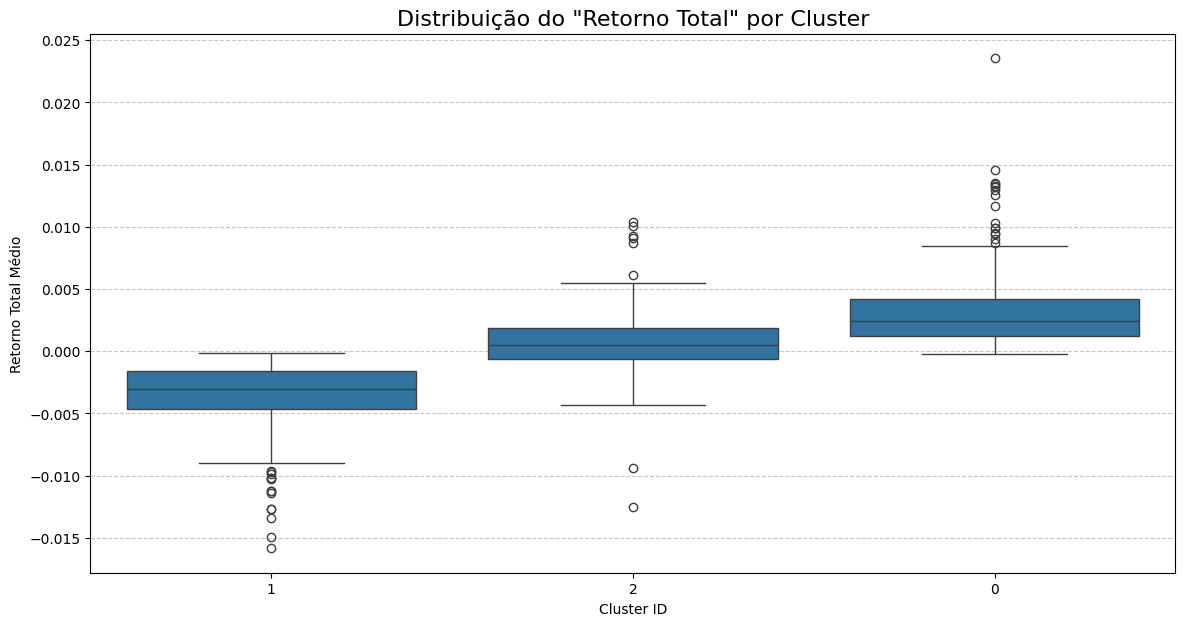


[5/6] Mapeando os clusters para os labels finais...
Mapeamento concluído. Labels gerados:
{np.int32(1): 'Venda', np.int32(2): 'Lateral', np.int32(0): 'Compra'}


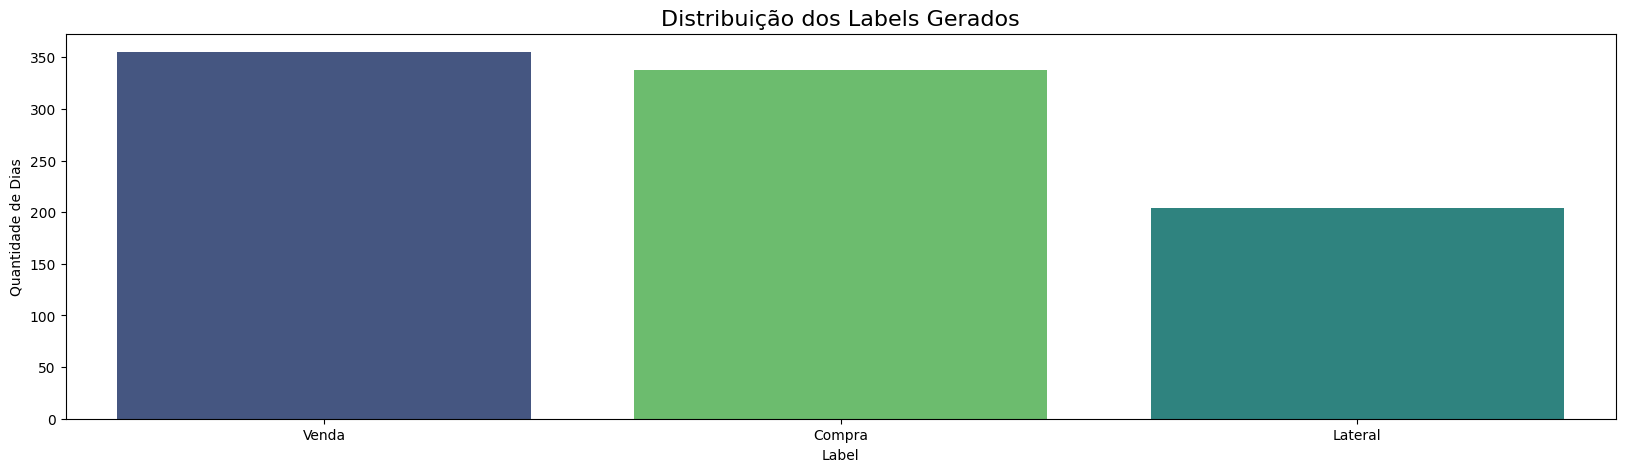


[6/6] Salvando o DataFrame com os labels no arquivo: dados_com_3_labels_3_features.csv

Processo da Fase 1 concluído com sucesso!
Amostra do arquivo final gerado:


,label,cluster,retorno_total,pavio_contra
datetime,,,,
2022-06-13,Venda,1,-0.000244,0.001853
2022-06-14,Venda,1,-0.008699,0.001458
2022-06-15,Venda,1,-0.005333,0.000425
2022-06-17,Venda,1,-0.012723,0.000245
2022-06-20,Lateral,2,0.010420,0.003076



--- [7/7] Identificando os dias que são outliers ---

Analisando outliers para o Cluster 0 ('Compra')...
Encontrados 16 outliers:


,label,retorno_total,volatilidade_total,volume_medio_normalizado
datetime,,,,
2022-06-22,Compra,0.009015,0.012651,0.038900
2022-07-15,Compra,0.010332,0.011682,0.035848
2022-09-02,Compra,0.012923,0.015285,0.040972
2022-09-19,Compra,0.009538,0.012263,0.047970
2022-10-03,Compra,0.009903,0.011037,0.043487
2022-11-24,Compra,0.014601,0.017349,0.051024
2022-11-29,Compra,0.013292,0.016060,0.046711
2022-12-02,Compra,0.023553,0.025034,0.058107
2023-02-13,Compra,0.013460,0.016151,0.053419



Analisando outliers para o Cluster 1 ('Venda')...
Encontrados 14 outliers:


,label,retorno_total,volatilidade_total,volume_medio_normalizado
datetime,,,,
2022-06-17,Venda,-0.012723,0.018449,0.040329
2022-09-15,Venda,-0.013398,0.014469,0.049733
2022-11-07,Venda,-0.015836,0.021534,0.047602
2022-11-18,Venda,-0.014960,0.021193,0.051020
2022-11-21,Venda,-0.011222,0.012709,0.046203
2022-12-12,Venda,-0.011425,0.018062,0.052710
2022-12-14,Venda,-0.009668,0.011002,0.045586
2023-01-06,Venda,-0.010183,0.011677,0.042272
2023-02-02,Venda,-0.010223,0.012790,0.044160



Analisando outliers para o Cluster 2 ('Lateral')...
Encontrados 8 outliers:


,label,retorno_total,volatilidade_total,volume_medio_normalizado
datetime,,,,
2022-06-20,Lateral,0.010420,0.013794,0.040371
2022-07-13,Lateral,0.009300,0.015366,0.045023
2022-08-02,Lateral,0.009107,0.015536,0.063633
2022-11-03,Lateral,0.010105,0.014429,0.039889
2022-11-04,Lateral,0.008692,0.013308,0.041973
2022-11-10,Lateral,-0.012487,0.025461,0.049357
2023-12-08,Lateral,0.006149,0.010552,0.055859
2025-04-08,Lateral,-0.009411,0.013860,0.041576


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'WIN_9h-12h.csv'
NOME_ARQUIVO_SAIDA = 'dados_com_3_labels_3_features.csv'
NUMERO_DE_CLUSTERS = 3 # Mantemos 6 para explorar, mas mapearemos para 5 labels

print("--- FASE 1: GERAÇÃO DE LABELS COM CLUSTERIZAÇÃO ---")

# --- PASSO 1: LEITURA E PREPARAÇÃO DOS DADOS ---
print(f"\n[1/6] Lendo o arquivo de dados: {NOME_ARQUIVO_ENTRADA}")
try:
    df_completo = pd.read_csv(NOME_ARQUIVO_ENTRADA, sep=';', parse_dates=['datetime'], index_col='datetime')
    print("Arquivo lido com sucesso.")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

# --- PASSO 2: CÁLCULO DAS FEATURES PARA LABELING (JANELA 11:00-11:55) ---
print("\n[2/6] Calculando as features descritivas para a janela das 11:00-11:55...")

df_janela_alvo = df_completo.between_time('11:00', '11:55')
#display(df_janela_alvo.head(30))

daily_agg_features = df_janela_alvo.resample('D').agg(  #  Agrupa todos os seus candles de 5 minutos por dia (.resample('D')).
    Abertura_11h=('Abertura', 'first'), # Crie uma nova coluna chamada Abertura_11h. Para cada grupo diário, encontre a coluna Abertura e pegue o primeiro (first) valor que você encontrar. (Que será, por definição, a abertura do primeiro candle daquele dia)."
    Fechamento_11h55=('Fechamento', 'last'),
    Maxima_periodo=('Maxima', 'max'),  # Crie uma nova coluna chamada Maxima_periodo. Para cada grupo diário, encontre a coluna Maxima e calcule o valor máximo (max) entre todos os candles daquele dia.
    Minima_periodo=('Minima', 'min'),
    Volume_Real_Medio=('Volume_Real', 'mean')  # Cria uma nova coluna "Volume_Real_Medio". Para cada dia encontra a coluna "Volume_Real" e calcula a média entre 11h00 e 11h55. 
)
# O 'D' significa "dia calendário". Isso significa que o pandas cria uma linha para todos os dias no seu intervalo de tempo, incluindo sábados, domingos e feriados.
daily_agg_features.dropna(inplace=True)  # remover linhas ou colunas que contêm valores ausentes.
#display(daily_agg_features.head(30))

# Cálculo das features de labeling
daily_agg_features['retorno_total'] = (daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']) / daily_agg_features['Abertura_11h']
daily_agg_features['volatilidade_total'] = (daily_agg_features['Maxima_periodo'] - daily_agg_features['Minima_periodo']) / daily_agg_features['Abertura_11h']
daily_agg_features['posicao_fechamento'] = (daily_agg_features['Fechamento_11h55'] - daily_agg_features['Minima_periodo']) / (daily_agg_features['Maxima_periodo'] - daily_agg_features['Minima_periodo'])
daily_agg_features['drawdown_maximo'] = (daily_agg_features['Abertura_11h'] - daily_agg_features['Minima_periodo']) / daily_agg_features['Abertura_11h']
daily_agg_features['runup_maximo'] = (daily_agg_features['Maxima_periodo'] - daily_agg_features['Abertura_11h']) / daily_agg_features['Abertura_11h']
#display(daily_agg_features.head(30))

# Cálculo do Volume Normalizado
daily_total_volume = df_completo['Volume_Real'].resample('D').sum()  # Calcular o volume total negociado em cada dia inteiro
daily_total_volume_rolling_avg = daily_total_volume.rolling(window=20, min_periods=1).mean()   # Calcular a média móvel de 20 dias do volume total diário.
daily_agg_features['volume_medio_normalizado'] = daily_agg_features['Volume_Real_Medio'] / daily_total_volume_rolling_avg  #  Criar a feature final de volume normalizado
# volume_medio_normalizado > 1.0: Volume na janela foi maior que a média recente.
# volume_medio_normalizado < 1.0: Volume na janela foi menor que a média recente.
daily_agg_features.replace([np.inf, -np.inf], np.nan, inplace=True)  # Limpar valores infinitos que podem ter surgido de divisões por zero.
daily_agg_features.dropna(inplace=True)  # Remover todas as linhas que ainda contêm qualquer valor ausente (NaN).
#display(daily_agg_features.head(30))

# --- CRIAÇÃO DA NOVA FEATURE 'pavio_contra' ---
# A condição que vamos testar
condicao_alta = daily_agg_features['retorno_total'] >= 0
# Os valores a serem usados dependendo da condição
valor_se_alta = daily_agg_features['drawdown_maximo'] # Pavio inferior
valor_se_baixa = daily_agg_features['runup_maximo']   # Pavio superior
# Usamos np.where para criar a coluna condicionalmente
daily_agg_features['pavio_contra'] = np.where(condicao_alta, valor_se_alta, valor_se_baixa)


# Seleciona apenas as colunas de features para a clusterização
'''
features_para_cluster = [
    'retorno_total', 'volatilidade_total', 'posicao_fechamento',
    'drawdown_maximo', 'runup_maximo', 'volume_medio_normalizado'
]
'''
features_para_cluster = [
    'retorno_total', 'pavio_contra'
]

print(f"{len(daily_agg_features)} dias de dados preparados para clusterização.")

# --- PASSO 3: PADRONIZAÇÃO E K-MEANS ---
print("\n[3/6] Padronizando features e aplicando o algoritmo K-Means...")

scaler = StandardScaler()
# Usamos .loc para selecionar os dados e evitar o warning
features_padronizadas = scaler.fit_transform(daily_agg_features.loc[:, features_para_cluster])

kmeans = KMeans(n_clusters=NUMERO_DE_CLUSTERS, random_state=42, n_init='auto')
# Adiciona a coluna de cluster diretamente ao DataFrame principal usando .loc
daily_agg_features.loc[:, 'cluster'] = kmeans.fit_predict(features_padronizadas)
print("Clusterização concluída.")
#display(daily_agg_features.head(30))

# --- PASSO 4: ANÁLISE E INTERPRETAÇÃO DOS CLUSTERS ---
print("\n[4/6] Analisando os centróides dos clusters para interpretação...")

# Agrupa por cluster e calcula a média de cada feature para entender sua "personalidade"
cluster_analysis = daily_agg_features.groupby('cluster')[features_para_cluster].mean().sort_values('retorno_total')

print("Análise dos Clusters (Médias das Features por Cluster):")
# Mostra a tabela de análise para ajudar na interpretação manual
display(cluster_analysis)

# Visualização dos clusters para facilitar a interpretação
plt.figure(figsize=(14, 7))
sns.boxplot(data=daily_agg_features, x='cluster', y='retorno_total', order=cluster_analysis.index)
plt.title('Distribuição do "Retorno Total" por Cluster', fontsize=16)
plt.ylabel('Retorno Total Médio')
plt.xlabel('Cluster ID')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- PASSO 5: MAPEAMENTO DOS CLUSTERS PARA LABELS SIGNIFICATIVOS ---
print("\n[5/6] Mapeando os clusters para os labels finais...")

# Com base na nossa análise detalhada dos seus resultados, este é o mapeamento mais acurado.
# Os IDs dos clusters (0, 1, 2, etc.) podem mudar se os dados mudarem,
# mas a lógica de mapeamento baseada na tabela de análise permanece a mesma.
'''
label_map = {
    cluster_analysis.index[0]: 'Super Venda',
    cluster_analysis.index[1]: 'Venda',
    cluster_analysis.index[2]: 'Lateral',
    cluster_analysis.index[3]: 'Lateral',
    cluster_analysis.index[4]: 'Compra',
    cluster_analysis.index[5]: 'Super Compra',
}


label_map = {
    cluster_analysis.index[0]: 'Super Venda',
    cluster_analysis.index[1]: 'Venda',
    cluster_analysis.index[2]: 'Lateral de Baixa Volatilidade',
    cluster_analysis.index[3]: 'Lateral de Alta Volatilidade',
    cluster_analysis.index[4]: 'Compra',
    cluster_analysis.index[5]: 'Super Compra',
}
'''

label_map = {
    cluster_analysis.index[0]: 'Venda',
    cluster_analysis.index[1]: 'Lateral',
    cluster_analysis.index[2]: 'Compra'
}

# APLIQUE SEU MAPEAMENTO AQUI
# Ex: label_map = {0: 'Super Venda', 1: 'Venda', ...}
#  traduz os números abstratos dos clusters em nomes humanos e significativos.
daily_agg_features.loc[:, 'label'] = daily_agg_features['cluster'].map(label_map)
print("Mapeamento concluído. Labels gerados:")
print(label_map)

# Gráfico de contagem para verificar o balanceamento das classes
plt.figure(figsize=(20, 5))
sns.countplot(
    data=daily_agg_features, 
    x='label', 
    order=daily_agg_features['label'].value_counts().index, 
    palette='viridis',
    hue='label',  # Adicionado para ser explícito
    legend=False  # Adicionado para remover a legenda redundante
)
plt.title('Distribuição dos Labels Gerados', fontsize=16)
plt.ylabel('Quantidade de Dias')
plt.xlabel('Label')
plt.show()


# --- PASSO 6: SALVAR O RESULTADO FINAL ---
print(f"\n[6/6] Salvando o DataFrame com os labels no arquivo: {NOME_ARQUIVO_SAIDA}")

# Seleciona as colunas relevantes para salvar
df_final_com_labels = daily_agg_features[['label', 'cluster'] + features_para_cluster].copy()

df_final_com_labels.to_csv(NOME_ARQUIVO_SAIDA, sep=';')

print("\nProcesso da Fase 1 concluído com sucesso!")
print("Amostra do arquivo final gerado:")
display(df_final_com_labels.head())


# --- PASSO 7 (BÔNUS): IDENTIFICAÇÃO DE OUTLIERS ---

print("\n--- [7/7] Identificando os dias que são outliers ---")

# A feature que queremos usar para identificar os outliers
feature_outlier = 'retorno_total'

# Itera sobre cada cluster que foi gerado
for cluster_id in sorted(daily_agg_features['cluster'].unique()):
    
    # Filtra o DataFrame para conter apenas os dados do cluster atual
    df_cluster = daily_agg_features[daily_agg_features['cluster'] == cluster_id]
    
    # Pega o label correspondente para usar no print
    label_nome = df_cluster['label'].iloc[0]
    
    print(f"\nAnalisando outliers para o Cluster {cluster_id} ('{label_nome}')...")
    
    # Calcula Q1, Q3 e IQR para a feature de interesse dentro deste cluster
    Q1 = df_cluster[feature_outlier].quantile(0.25)
    Q3 = df_cluster[feature_outlier].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define os limites para detecção de outliers
    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR
    
    # Encontra os outliers
    outliers = df_cluster[
        (df_cluster[feature_outlier] > limite_superior) | 
        (df_cluster[feature_outlier] < limite_inferior)
    ]
    
    # Exibe os resultados
    if not outliers.empty:
        print(f"Encontrados {len(outliers)} outliers:")
        # Exibe os outliers com as features mais importantes para análise
        display(outliers[['label', feature_outlier, 'volatilidade_total', 'volume_medio_normalizado']])
    else:
        print("Nenhum outlier encontrado neste cluster.")




## Criando labels atraves da heurística
O código a baixo cria três labels (compra venda e lateral) usando apenas as seguintes features;
* retorno_total: Fechamento_11:55 - Abertura_11:00.
* pavio_contra:
  * quando retorno_total > 0 = Abertura_11 - Minima_periodo.
  * quando retorno_total < 0 = Maxima_periodo - Abertura_11.
  
1. Compra: quando o retorno total é positivo e maior que 50 pontos, e o pavio_contra é menor que 300 pontoas.
2. Venda: quando o retorno total é negativo e maior que 50 pontos, e o pavio_contra é menor que 300 pontoas.
3. Lateral demais casos.


[ETAPA 0/5] Lendo e agregando os dados de 'WIN$N_M5_5_ANOS_BRUTO.csv'...
DataFrame 'daily_agg_features' criado com 897 dias de pregão.

[ETAPA 1/5] Calculando as features em pontos absolutos...
Features em pontos calculadas com sucesso.

[ETAPA 2/5] Definindo as novas condições (Compra/Venda/Lateral)...
Condições e labels definidos.

[ETAPA 3/5] Aplicando as regras para gerar a coluna 'label'...
Coluna 'label' gerada com sucesso.

[ETAPA 4/5] Analisando a distribuição dos labels gerados...
Distribuição dos Labels:
label
Venda      319
Compra     298
Lateral    280
Name: count, dtype: int64


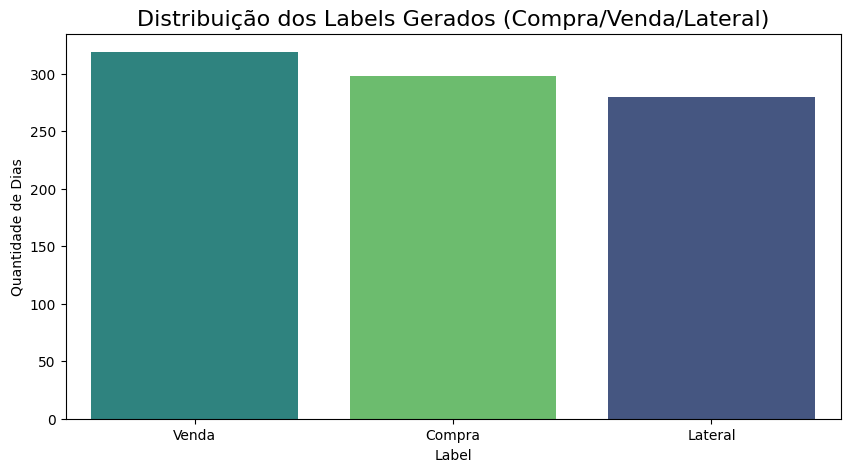


[ETAPA 5/5] Salvando e exibindo o resultado final...
Arquivo 'labels.csv' salvo com sucesso.

Amostra do DataFrame com os labels finais:


,retorno_total,pavio_contra,label
datetime,,,
2022-06-13,-25.0,190.0,Lateral
2022-06-14,-895.0,150.0,Venda
2022-06-15,-565.0,45.0,Venda
2022-06-17,-1300.0,25.0,Venda
2022-06-20,1050.0,310.0,Lateral
2022-06-21,-355.0,130.0,Venda
2022-06-22,905.0,175.0,Compra
2022-06-23,380.0,435.0,Lateral
2022-06-24,360.0,5.0,Compra


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'WIN$N_M5_5_ANOS_BRUTO.csv'
NOME_ARQUIVO_SAIDA = 'labels.csv'

# --- ETAPA 0: LEITURA E AGREGAÇÃO DOS DADOS ---
print(f"\n[ETAPA 0/5] Lendo e agregando os dados de '{NOME_ARQUIVO_ENTRADA}'...")
try:
    df_completo = pd.read_csv(NOME_ARQUIVO_ENTRADA, sep=';', parse_dates=['datetime'], index_col='datetime')
    
    # Agrupa por dia para criar o DataFrame 'daily_agg_features'
    # A janela de interesse é das 11:00 às 11:55
    df_janela_alvo = df_completo.between_time('11:00', '11:55')
    daily_agg_features = df_janela_alvo.resample('D').agg(   #  Agrupa todos os seus candles de 5 minutos por dia (.resample('D')).
        Abertura_11h=('Abertura', 'first'),  # Crie uma nova coluna chamada Abertura_11h. Para cada grupo diário, encontre a coluna Abertura e pegue o primeiro (first) valor que você encontrar. (Que será, por definição, a abertura do primeiro candle daquele dia)."
        Fechamento_11h55=('Fechamento', 'last'),
        Maxima_periodo=('Maxima', 'max'),   # Crie uma nova coluna chamada Maxima_periodo. Para cada grupo diário, encontre a coluna Maxima e calcule o valor máximo (max) entre todos os candles daquele dia.
        Minima_periodo=('Minima', 'min')
    )

    # O 'D' significa "dia calendário". Isso significa que o pandas cria uma linha para todos os dias no seu intervalo de tempo, incluindo sábados, domingos e feriados.
    # Remove dias sem pregão (fins de semana, feriados)
    daily_agg_features.dropna(inplace=True)
    
    print(f"DataFrame 'daily_agg_features' criado com {len(daily_agg_features)} dias de pregão.")

except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado. Verifique o nome e o caminho.")
    exit()
except Exception as e:
    print(f"Ocorreu um erro inesperado ao ler ou agregar os dados: {e}")
    exit()


# --- PASSO 1: CALCULAR AS FEATURES EM PONTOS ---
print("\n[ETAPA 1/5] Calculando as features em pontos absolutos...")

daily_agg_features['retorno_total'] = (
    daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']
)

condicao_alta = daily_agg_features['retorno_total'] >= 0
pavio_inferior_pontos = daily_agg_features['Abertura_11h'] - daily_agg_features['Minima_periodo']
pavio_superior_pontos = daily_agg_features['Maxima_periodo'] - daily_agg_features['Abertura_11h']
daily_agg_features['pavio_contra'] = np.where(
    condicao_alta, 
    pavio_inferior_pontos, 
    pavio_superior_pontos
)
print("Features em pontos calculadas com sucesso.")


# --- PASSO 2: DEFINIR AS NOVAS CONDIÇÕES E LABELS ---
print("\n[ETAPA 2/5] Definindo as novas condições (Compra/Venda/Lateral)...")

condicoes = [
    # 1. Compra: Retorno > 50 pontos E Risco < 300 pontos
    (daily_agg_features['retorno_total'] > 50) & (daily_agg_features['pavio_contra'] < 250),
    
    # 2. Venda: Retorno < -50 pontos E Risco < 300 pontos
    (daily_agg_features['retorno_total'] < -50) & (daily_agg_features['pavio_contra'] < 250),
]

# Lista de labels correspondente
labels = [
    'Compra',
    'Venda',
]
print("Condições e labels definidos.")


# --- PASSO 3: APLICAR AS REGRAS PARA CRIAR A COLUNA 'label' ---
print("\n[ETAPA 3/5] Aplicando as regras para gerar a coluna 'label'...")

# O 'default' agora é 'Lateral' para qualquer dia que não atenda às condições de Compra ou Venda.
daily_agg_features['label'] = np.select(condicoes, labels, default='Lateral')
print("Coluna 'label' gerada com sucesso.")


# --- PASSO 4: ANÁLISE DA DISTRIBUIÇÃO DOS LABELS ---
print("\n[ETAPA 4/5] Analisando a distribuição dos labels gerados...")

label_counts = daily_agg_features['label'].value_counts()
print("Distribuição dos Labels:")
print(label_counts)

plt.figure(figsize=(10, 5))
sns.countplot(
    data=daily_agg_features, 
    x='label', # Usando x agora que os nomes são curtos
    order=label_counts.index,
    palette='viridis',
    hue='label',
    legend=False
)
plt.title('Distribuição dos Labels Gerados (Compra/Venda/Lateral)', fontsize=16)
plt.ylabel('Quantidade de Dias')
plt.xlabel('Label')
plt.show()


# --- PASSO 5: SALVAR E EXIBIR O RESULTADO ---
print("\n[ETAPA 5/5] Salvando e exibindo o resultado final...")

# Seleciona as colunas mais relevantes para salvar e analisar
df_final_com_labels = daily_agg_features[[
    'retorno_total', 
    'pavio_contra', 
    'label'
]].copy()

# Salva o arquivo final
df_final_com_labels.to_csv(NOME_ARQUIVO_SAIDA, sep=';')
print(f"Arquivo '{NOME_ARQUIVO_SAIDA}' salvo com sucesso.")

print("\nAmostra do DataFrame com os labels finais:")
display(df_final_com_labels.head(10))


## Engenharia de Features e Achatamento
O código a seguir faz o seguinte:

1. abre o dataframe WIN$N_M5_5_ANOS_BRUTO.csv.
2. Agrupa por dia para criar o DataFrame 'daily_agg_features'. A janela de interesse é das 11:00 às 11:55
3. usa as velas das 11:00 até 11:55 para criar variáveis que serão usadas para criar as features, as features serão usada para criar as label (compra, venda, lateral).
4. CALCULAR AS FEATURES EM PONTOS.
5. DEFINIR AS NOVAS CONDIÇÕES E LABELS
6. APLICAR AS REGRAS PARA CRIAR A COLUNA 'label'
7. ANÁLISE DA DISTRIBUIÇÃO DOS LABELS
8. EXIBIR O RESULTADO
9. Seleciona as colunas mais relevantes para salvar e analisar
10. A partir de df_completo, calcula as features de engenharia para todos os candles:
11. Achatando os dados com a ordem correta (por candle) apenas do horário das 09:00 às 11:55.
12. Codificando labels (One-Hot) 
13. Juntar as features de entrada (`X`) e os labels codificados (`Y`) em um único DataFrame.
14. Salvando o dataset bruto final (dataset_bruto.csv)

Biblioteca TA-Lib encontrada.

--- FASE 1: GERAÇÃO DE LABELS ---

[ETAPA 1/5] Lendo e agregando os dados de 'WIN$N_M5_5_ANOS_BRUTO.csv'...
Conversão para tipo numérico concluída. Tipos de dados das colunas:
Abertura       int64
Maxima         int64
Minima         int64
Fechamento     int64
Volume_Real    int64
Volume_Tick    int64
dtype: object
DataFrame 'daily_agg_features' para labels criado com 897 dias.

[ETAPA 2/5] Calculando features para os labels...

[ETAPA 3/5] Aplicando regras para gerar a coluna 'label'...

[ETAPA 4/5] Analisando a distribuição dos labels gerados...
label
Venda      319
Compra     298
Lateral    280
Name: count, dtype: int64


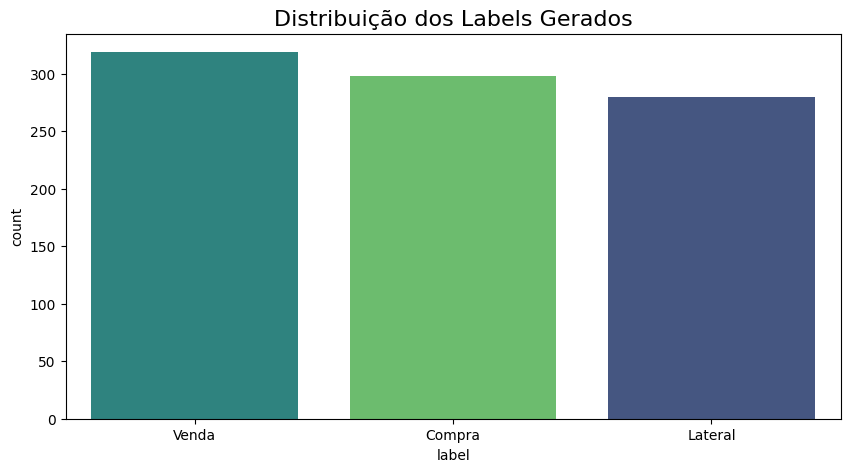


--- FASE 1 CONCLUÍDA: LABELS GERADOS EM MEMÓRIA ---

--- FASE 2: GERAÇÃO DAS FEATURES DE ENTRADA (X) ---

[ETAPA 6/9] Calculando as 11 features para cada candle de 5 minutos...
Features de entrada calculadas com sucesso.

[ETAPA 7/9] Achatando os dados com a ordem correta (por candle)...
DataFrame de features de entrada (X) achatado com a ordem correta.

[ETAPA 8/9] Codificando labels (One-Hot) e juntando os DataFrames...
Junção de features e labels codificados concluída.

[ETAPA 9/9] Salvando o dataset bruto final em 'dataset_final.csv'...

--- PROCESSAMENTO COMPLETO ---
Dimensões do DataFrame final (dias, features + labels): (891, 267)
Total de dias válidos no dataset final: 891

Amostra do dataset bruto final (features do primeiro e segundo candle, e labels):


,mag_decisao_c1,mov_direcional_c1,pavio_superior_c1,pavio_inferior_c1,range_candle_c1,volume_real_norm_c1,volume_tick_norm_c1,tamanho_medio_ordem_c1,diferenca_MA_c1,RSI_c1,MACD_c1,mag_decisao_c2,mov_direcional_c2,pavio_superior_c2,pavio_inferior_c2,range_candle_c2,volume_real_norm_c2,volume_tick_norm_c2,tamanho_medio_ordem_c2,diferenca_MA_c2,RSI_c2,MACD_c2,mag_decisao_c3,mov_direcional_c3,pavio_superior_c3,pavio_inferior_c3,range_candle_c3,volume_real_norm_c3,volume_tick_norm_c3,tamanho_medio_ordem_c3,diferenca_MA_c3,RSI_c3,MACD_c3,mag_decisao_c4,mov_direcional_c4,pavio_superior_c4,pavio_inferior_c4,range_candle_c4,volume_real_norm_c4,volume_tick_norm_c4,tamanho_medio_ordem_c4,diferenca_MA_c4,RSI_c4,MACD_c4,mag_decisao_c5,mov_direcional_c5,pavio_superior_c5,pavio_inferior_c5,range_candle_c5,volume_real_norm_c5,volume_tick_norm_c5,tamanho_medio_ordem_c5,diferenca_MA_c5,RSI_c5,MACD_c5,mag_decisao_c6,mov_direcional_c6,pavio_superior_c6,pavio_inferior_c6,range_candle_c6,volume_real_norm_c6,volume_tick_norm_c6,tamanho_medio_ordem_c6,diferenca_MA_c6,RSI_c6,MACD_c6,mag_decisao_c7,mov_direcional_c7,pavio_superior_c7,pavio_inferior_c7,range_candle_c7,volume_real_norm_c7,volume_tick_norm_c7,tamanho_medio_ordem_c7,diferenca_MA_c7,RSI_c7,MACD_c7,mag_decisao_c8,mov_direcional_c8,pavio_superior_c8,pavio_inferior_c8,range_candle_c8,volume_real_norm_c8,volume_tick_norm_c8,tamanho_medio_ordem_c8,diferenca_MA_c8,RSI_c8,MACD_c8,mag_decisao_c9,mov_direcional_c9,pavio_superior_c9,pavio_inferior_c9,range_candle_c9,volume_real_norm_c9,volume_tick_norm_c9,tamanho_medio_ordem_c9,diferenca_MA_c9,RSI_c9,MACD_c9,mag_decisao_c10,mov_direcional_c10,pavio_superior_c10,pavio_inferior_c10,range_candle_c10,volume_real_norm_c10,volume_tick_norm_c10,tamanho_medio_ordem_c10,diferenca_MA_c10,RSI_c10,MACD_c10,mag_decisao_c11,mov_direcional_c11,pavio_superior_c11,pavio_inferior_c11,range_candle_c11,volume_real_norm_c11,volume_tick_norm_c11,tamanho_medio_ordem_c11,diferenca_MA_c11,RSI_c11,MACD_c11,mag_decisao_c12,mov_direcional_c12,pavio_superior_c12,pavio_inferior_c12,range_candle_c12,volume_real_norm_c12,volume_tick_norm_c12,tamanho_medio_ordem_c12,diferenca_MA_c12,RSI_c12,MACD_c12,mag_decisao_c13,mov_direcional_c13,pavio_superior_c13,pavio_inferior_c13,range_candle_c13,volume_real_norm_c13,volume_tick_norm_c13,tamanho_medio_ordem_c13,diferenca_MA_c13,RSI_c13,MACD_c13,mag_decisao_c14,mov_direcional_c14,pavio_superior_c14,pavio_inferior_c14,range_candle_c14,volume_real_norm_c14,volume_tick_norm_c14,tamanho_medio_ordem_c14,diferenca_MA_c14,RSI_c14,MACD_c14,mag_decisao_c15,mov_direcional_c15,pavio_superior_c15,pavio_inferior_c15,range_candle_c15,volume_real_norm_c15,volume_tick_norm_c15,tamanho_medio_ordem_c15,diferenca_MA_c15,RSI_c15,MACD_c15,mag_decisao_c16,mov_direcional_c16,pavio_superior_c16,pavio_inferior_c16,range_candle_c16,volume_real_norm_c16,volume_tick_norm_c16,tamanho_medio_ordem_c16,diferenca_MA_c16,RSI_c16,MACD_c16,mag_decisao_c17,mov_direcional_c17,pavio_superior_c17,pavio_inferior_c17,range_candle_c17,volume_real_norm_c17,volume_tick_norm_c17,tamanho_medio_ordem_c17,diferenca_MA_c17,RSI_c17,MACD_c17,mag_decisao_c18,mov_direcional_c18,pavio_superior_c18,pavio_inferior_c18,range_candle_c18,volume_real_norm_c18,volume_tick_norm_c18,tamanho_medio_ordem_c18,diferenca_MA_c18,RSI_c18,MACD_c18,mag_decisao_c19,mov_direcional_c19,pavio_superior_c19,pavio_inferior_c19,range_candle_c19,volume_real_norm_c19,volume_tick_norm_c19,tamanho_medio_ordem_c19,diferenca_MA_c19,RSI_c19,MACD_c19,mag_decisao_c20,mov_direcional_c20,pavio_superior_c20,pavio_inferior_c20,range_candle_c20,volume_real_norm_c20,volume_tick_norm_c20,tamanho_medio_ordem_c20,diferenca_MA_c20,RSI_c20,MACD_c20,mag_decisao_c21,mov_direcional_c21,pavio_superior_c21,pavio_inferior_c21,range_candle_c21,volume_real_norm_c21,volume_tick_norm_c21,tamanho_medio_ordem_c21,diferenca_MA_c21,RSI_c21,MACD_c21,mag_decisao_c22,mov_direcional_c22,pavio_superior_c22,pavio_inferior_c22,range_candle_c22,volume_real_norm_c

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tenta usar a biblioteca TA-Lib se estiver instalada
try:
    import talib
    TALIB_INSTALLED = True
    print("Biblioteca TA-Lib encontrada.")
except ImportError:
    TALIB_INSTALLED = False
    print("Biblioteca TA-Lib não encontrada. Usando implementações alternativas.")

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'WIN$N_M5_5_ANOS_BRUTO.csv'
NOME_ARQUIVO_SAIDA_FINAL = 'dataset_final.csv'

# --- FASE 1: GERAÇÃO DE LABELS (LÓGICA MANTIDA) ---
print(f"\n--- FASE 1: GERAÇÃO DE LABELS ---")
print(f"\n[ETAPA 1/5] Lendo e agregando os dados de '{NOME_ARQUIVO_ENTRADA}'...")
try:
    df_completo = pd.read_csv(NOME_ARQUIVO_ENTRADA, sep=';', parse_dates=['datetime'], index_col='datetime')

    # Lista de colunas que devem ser numéricas
    colunas_numericas = ['Abertura', 'Maxima', 'Minima', 'Fechamento', 'Volume_Real', 'Volume_Tick']

    # Força a conversão para tipo numérico.
    # 'errors='coerce'' transforma qualquer valor que não possa ser convertido em NaN (Not a Number).
    for col in colunas_numericas:
        df_completo[col] = pd.to_numeric(df_completo[col], errors='coerce')
        
    # Remove qualquer linha que possa ter gerado um NaN durante a conversão
    # Isso garante que só trabalharemos com dados 100% numéricos e válidos.
    df_completo.dropna(subset=colunas_numericas, inplace=True)
    
    print("Conversão para tipo numérico concluída. Tipos de dados das colunas:")
    print(df_completo[colunas_numericas].dtypes)
    
    df_janela_alvo = df_completo.between_time('11:00', '11:55')
    daily_agg_features = df_janela_alvo.resample('D').agg(
        Abertura_11h=('Abertura', 'first'),
        Fechamento_11h55=('Fechamento', 'last'),
        Maxima_periodo=('Maxima', 'max'),
        Minima_periodo=('Minima', 'min')
    )
    daily_agg_features.dropna(inplace=True)
    print(f"DataFrame 'daily_agg_features' para labels criado com {len(daily_agg_features)} dias.")
except Exception as e:
    print(f"ERRO ao ler ou agregar os dados: {e}")
    exit()

print("\n[ETAPA 2/5] Calculando features para os labels...")
daily_agg_features['retorno_total'] = daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']
condicao_alta = daily_agg_features['retorno_total'] >= 0
pavio_inferior_pontos = daily_agg_features['Abertura_11h'] - daily_agg_features['Minima_periodo']
pavio_superior_pontos = daily_agg_features['Maxima_periodo'] - daily_agg_features['Abertura_11h']
daily_agg_features['pavio_contra'] = np.where(condicao_alta, pavio_inferior_pontos, pavio_superior_pontos)

print("\n[ETAPA 3/5] Aplicando regras para gerar a coluna 'label'...")
condicoes = [
    (daily_agg_features['retorno_total'] > 50) & (daily_agg_features['pavio_contra'] < 250),
    (daily_agg_features['retorno_total'] < -50) & (daily_agg_features['pavio_contra'] < 250),
]
labels = ['Compra', 'Venda']
daily_agg_features['label'] = np.select(condicoes, labels, default='Lateral')

print("\n[ETAPA 4/5] Analisando a distribuição dos labels gerados...")
print(daily_agg_features['label'].value_counts())
plt.figure(figsize=(10, 5))
sns.countplot(data=daily_agg_features, x='label', order=daily_agg_features['label'].value_counts().index, palette='viridis', hue='label', legend=False)
plt.title('Distribuição dos Labels Gerados', fontsize=16)
plt.show()
print("\n--- FASE 1 CONCLUÍDA: LABELS GERADOS EM MEMÓRIA ---")


# --- FASE 2: GERAÇÃO DAS FEATURES DE ENTRADA (X) ---
print("\n--- FASE 2: GERAÇÃO DAS FEATURES DE ENTRADA (X) ---")

# --- ETAPA 6/9: CÁLCULO DAS FEATURES POR CANDLE ---
print("\n[ETAPA 6/9] Calculando as 11 features para cada candle de 5 minutos...")
df_completo.replace(0, 1e-9, inplace=True)
df_completo['mag_decisao'] = abs(df_completo['Fechamento'] - df_completo['Abertura']) / df_completo['Abertura']
df_completo['mov_direcional'] = np.sign(df_completo['Fechamento'] - df_completo['Abertura'])
df_completo['pavio_superior'] = (df_completo['Maxima'] - df_completo[['Abertura', 'Fechamento']].max(axis=1)) / df_completo['Abertura']
df_completo['pavio_inferior'] = (df_completo[['Abertura', 'Fechamento']].min(axis=1) - df_completo['Minima']) / df_completo['Abertura']
df_completo['range_candle'] = (df_completo['Maxima'] - df_completo['Minima']) / df_completo['Abertura']
vol_real_baseline = df_completo['Volume_Real'].rolling(window=50, min_periods=1).mean()
vol_tick_baseline = df_completo['Volume_Tick'].rolling(window=50, min_periods=1).mean()
df_completo['volume_real_norm'] = df_completo['Volume_Real'] / vol_real_baseline
df_completo['volume_tick_norm'] = df_completo['Volume_Tick'] / vol_tick_baseline
df_completo['tamanho_medio_ordem'] = df_completo['Volume_Real'] / df_completo['Volume_Tick']
ma_3 = df_completo['Fechamento'].rolling(window=3).mean()
ma_9 = df_completo['Fechamento'].rolling(window=9).mean()
df_completo['diferenca_MA'] = (ma_3 - ma_9) / df_completo['Fechamento']
if TALIB_INSTALLED:
    df_completo['RSI'] = talib.RSI(df_completo['Fechamento'], timeperiod=14)
    macd, macdsignal, _ = talib.MACD(df_completo['Fechamento'], fastperiod=12, slowperiod=26, signalperiod=9)
    df_completo['MACD'] = macd - macdsignal
else:
    delta = df_completo['Fechamento'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_completo['RSI'] = 100 - (100 / (1 + rs))
    ema_fast = df_completo['Fechamento'].ewm(span=12, adjust=False).mean()
    ema_slow = df_completo['Fechamento'].ewm(span=26, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    df_completo['MACD'] = macd_line - signal_line
df_completo.dropna(inplace=True)
print("Features de entrada calculadas com sucesso.")

# --- ETAPA 7/9: "ACHATAR" (FLATTEN) AS FEATURES COM A ORDEM CORRETA ---
print("\n[ETAPA 7/9] Achatando os dados com a ordem correta (por candle)...")

features_por_candle = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior',
    'range_candle', 'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem',
    'diferenca_MA', 'RSI', 'MACD'
]
'''
features_por_candle = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior',
    'range_candle', 'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem',
    'diferenca_MA']
'''
df_janela_entrada = df_completo.between_time('09:00', '10:55').copy()
df_janela_entrada['dia'] = df_janela_entrada.index.date
dias_completos = df_janela_entrada['dia'].value_counts()
dias_validos = dias_completos[dias_completos == 24].index
df_janela_valida = df_janela_entrada[df_janela_entrada['dia'].isin(dias_validos)].copy()

# --- LÓGICA DE REORDENAÇÃO E ACHATAMENTO ---
# 1. Agrupa os dados por dia
grouped_by_day = df_janela_valida.groupby('dia')

# 2. Para cada dia, achata as features dos 24 candles em uma única linha
daily_flattened_data = []
for day, group in grouped_by_day:
    # Pega apenas as colunas de features e transforma em um array 1D
    flattened_features = group[features_por_candle].values.flatten()
    daily_flattened_data.append(flattened_features)

# 3. Cria os nomes das colunas na ordem correta
colunas_ordenadas = []
for i in range(1, 25): # 24 candles
    for feature in features_por_candle:
        colunas_ordenadas.append(f'{feature}_c{i}')

# 4. Cria o DataFrame final de features
df_features_X = pd.DataFrame(
    daily_flattened_data,
    index=grouped_by_day.groups.keys(), # Usa os dias como índice
    columns=colunas_ordenadas
)
df_features_X.index.name = 'datetime'
df_features_X.index = pd.to_datetime(df_features_X.index)
print("DataFrame de features de entrada (X) achatado com a ordem correta.")

# --- ETAPA 8/9: CODIFICAÇÃO ONE-HOT E JUNÇÃO DOS DADOS ---
print("\n[ETAPA 8/9] Codificando labels (One-Hot) e juntando os DataFrames...")
df_labels_Y = daily_agg_features[['label']]
df_labels_one_hot = pd.get_dummies(df_labels_Y['label'], prefix='label')
df_dataset_bruto = df_features_X.merge(df_labels_one_hot, left_index=True, right_index=True, how='inner').copy()
print("Junção de features e labels codificados concluída.")

# --- ETAPA 9/9: SALVAR E EXIBIR O DATASET BRUTO FINAL ---
print(f"\n[ETAPA 9/9] Salvando o dataset bruto final em '{NOME_ARQUIVO_SAIDA_FINAL}'...")
df_dataset_bruto.to_csv(NOME_ARQUIVO_SAIDA_FINAL, sep=';')

print(f"\n--- PROCESSAMENTO COMPLETO ---")
print(f"Dimensões do DataFrame final (dias, features + labels): {df_dataset_bruto.shape}")
print(f"Total de dias válidos no dataset final: {len(df_dataset_bruto)}")

print("\nAmostra do dataset bruto final (features do primeiro e segundo candle, e labels):")
# Mostra as primeiras 11 colunas (candle 1), as próximas 11 (candle 2) e as 3 últimas (labels)
#colunas_amostra = list(df_dataset_bruto.columns[0:11]) + list(df_dataset_bruto.columns[11:22]) + list(df_dataset_bruto.columns[-3:])
#display(df_dataset_bruto[colunas_amostra].head())

# Ajuste nas opções de exibição do Pandas para mostrar mais colunas
# Isso ajuda a evitar que o Jupyter esconda colunas com "..."
pd.set_option('display.max_columns', 300) # Define um limite alto para o número de colunas a serem exibidas
display(df_dataset_bruto.head())
# Opcional: Restaurar as opções de exibição para o padrão depois de usar
pd.reset_option('display.max_columns')


# Tratando o dataset
Vamos criar um conjunto de treino com uma sequência perfeitamente ordenada e cíclica (`Compra`, `Venda`, `Lateral`, `Compra`, `Venda`, `Lateral`...).

Esta é uma forma de **amostragem estratificada e ordenada**. É uma abordagem interessante para garantir que cada lote de treinamento (se o tamanho do lote for um múltiplo de 3) seja perfeitamente balanceado.

## Análise da Lógica

1.  **Carregar e Separar:** Primeiro, carregamos o dataset e separamos `X` e `Y`.
2.  **Divisão Cronológica:** Dividimos em treino e teste **sem embaralhar (`shuffle=False`)**. Isso é crucial para que o conjunto de teste permaneça no "futuro".
3.  **Separar por Classe:** Pegamos o conjunto de treino e o dividimos em três DataFrames menores: um apenas com as 'Compras', um com as 'Vendas' e um com as 'Laterais'.
4.  **Encontrar o Tamanho Mínimo:** Identificamos qual classe tem o menor número de amostras. Isso determinará o tamanho do nosso novo conjunto de treino balanceado (para não ficarmos sem amostras de uma classe).
5.  **Intercalar (A Mágica):** Criamos um novo DataFrame de treino vazio. Em um loop, pegamos a primeira linha do DataFrame de 'Compra', depois a primeira de 'Venda', depois a primeira de 'Lateral'. Em seguida, a segunda de 'Compra', a segunda de 'Venda', a segunda de 'Lateral', e assim por diante, até esgotarmos as amostras da classe minoritária.
6.  **Finalizar:** O resultado é um conjunto de treino perfeitamente ordenado e balanceado, pronto para ser usado no `model.fit()`.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

print(f"\n--- SCRIPT DE REORGANIZAÇÃO ORDENADA DO DATASET DE TREINO ---")

# --- ETAPA 1: CARREGAR E SEPARAR X E Y ---
print("\n[ETAPA 1/5] Carregando o dataset e separando Features (X) e Alvo (Y)...")
try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col='datetime', sep=';')
    
    # Identifica as colunas de label e de features
    label_cols = ['label_Compra', 'label_Lateral', 'label_Venda']
    feature_cols = [col for col in df.columns if col not in label_cols]
    
    X_flat = df[feature_cols]
    Y = df[label_cols]
    print(f"Dataset carregado com {len(df)} dias.")
    
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o arquivo: {e}")
    exit()

# --- ETAPA 2: DIVISÃO CRONOLÓGICA EM TREINO E TESTE ---
print("\n[ETAPA 2/5] Dividindo em conjuntos de treino e teste (80/20, cronológico)...")
X_train_orig, X_test, Y_train_orig, Y_test = train_test_split(
    X_flat, Y, test_size=0.2, shuffle=False
)

print(f"Tamanho do conjunto de treino original: {len(X_train_orig)} dias.")
print(f"Tamanho do conjunto de teste: {len(X_test)} dias.")

# --- ETAPA 3: SEPARAR O CONJUNTO DE TREINO POR CLASSE ---
print("\n[ETAPA 3/5] Separando o conjunto de treino por classe...")

# Adiciona a coluna de label original de volta para facilitar a filtragem
Y_train_orig_labels = Y_train_orig.idxmax(axis=1)
X_train_orig['label'] = Y_train_orig_labels

# Cria um DataFrame para cada classe
df_compra = X_train_orig[X_train_orig['label'] == 'label_Compra'].copy()
df_venda = X_train_orig[X_train_orig['label'] == 'label_Venda'].copy()
df_lateral = X_train_orig[X_train_orig['label'] == 'label_Lateral'].copy()

print(f"Amostras de Compra no treino: {len(df_compra)}")
print(f"Amostras de Venda no treino: {len(df_venda)}")
print(f"Amostras de Lateral no treino: {len(df_lateral)}")

# Remove a coluna 'label' temporária
df_compra.drop('label', axis=1, inplace=True)
df_venda.drop('label', axis=1, inplace=True)
df_lateral.drop('label', axis=1, inplace=True)

# --- ETAPA 4: INTERCALAR AS CLASSES PARA CRIAR O NOVO CONJUNTO DE TREINO ---
print("\n[ETAPA 4/5] Intercalando as classes para criar um conjunto de treino ordenado e balanceado...")

# Encontra o número de amostras da classe minoritária
min_samples = min(len(df_compra), len(df_venda), len(df_lateral))
print(f"O novo conjunto de treino terá {min_samples} amostras de cada classe, totalizando {min_samples * 3} dias.")

# Pega apenas o número 'min_samples' de cada DataFrame
df_compra = df_compra.iloc[:min_samples]
df_venda = df_venda.iloc[:min_samples]
df_lateral = df_lateral.iloc[:min_samples]

# Lista para armazenar os DataFrames na ordem correta
ordered_dfs = []
for i in range(min_samples):
    ordered_dfs.append(df_compra.iloc[i:i+1])
    ordered_dfs.append(df_venda.iloc[i:i+1])
    ordered_dfs.append(df_lateral.iloc[i:i+1])

# Concatena todos os pequenos DataFrames em um único DataFrame final
df_train_ordered = pd.concat(ordered_dfs)

# Separa novamente em X e Y
X_train_ordered = df_train_ordered[feature_cols]
Y_train_ordered = pd.get_dummies(df_train_ordered.index.map(Y.idxmax(axis=1))) # Pega os labels correspondentes

print("Conjunto de treino reordenado criado com sucesso.")

# --- ETAPA 5: VERIFICAÇÃO FINAL ---
print("\n[ETAPA 5/5] Verificação do resultado final...")
print("\nPrimeiras 10 linhas do conjunto de treino ordenado (Y_train_ordered):")
#display(X_train_ordered.head(10))
display(Y_train_ordered.head(10))

print("\nÚltimas 10 linhas do conjunto de treino ordenado (Y_train_ordered):")
display(Y_train_ordered.tail(10))

print(f"\nFormato final de X_train_ordered: {X_train_ordered.shape}")
print(f"Formato final de Y_train_ordered: {Y_train_ordered.shape}")
print(f"Formato final de X_test (inalterado): {X_test.shape}")
print(f"Formato final de Y_test (inalterado): {Y_test.shape}")



--- SCRIPT DE REORGANIZAÇÃO ORDENADA DO DATASET DE TREINO ---

[ETAPA 1/5] Carregando o dataset e separando Features (X) e Alvo (Y)...
Dataset carregado com 891 dias.

[ETAPA 2/5] Dividindo em conjuntos de treino e teste (80/20, cronológico)...
Tamanho do conjunto de treino original: 712 dias.
Tamanho do conjunto de teste: 179 dias.

[ETAPA 3/5] Separando o conjunto de treino por classe...
Amostras de Compra no treino: 231
Amostras de Venda no treino: 261
Amostras de Lateral no treino: 220

[ETAPA 4/5] Intercalando as classes para criar um conjunto de treino ordenado e balanceado...
O novo conjunto de treino terá 220 amostras de cada classe, totalizando 660 dias.
Conjunto de treino reordenado criado com sucesso.

[ETAPA 5/5] Verificação do resultado final...

Primeiras 10 linhas do conjunto de treino ordenado (Y_train_ordered):


,label_Compra,label_Lateral,label_Venda
0,True,False,False
1,False,False,True
2,False,True,False
3,True,False,False
4,False,False,True
5,False,True,False
6,True,False,False
7,False,False,True
8,False,True,False
9,True,False,False



Últimas 10 linhas do conjunto de treino ordenado (Y_train_ordered):


,label_Compra,label_Lateral,label_Venda
650,False,True,False
651,True,False,False
652,False,False,True
653,False,True,False
654,True,False,False
655,False,False,True
656,False,True,False
657,True,False,False
658,False,False,True
659,False,True,False



Formato final de X_train_ordered: (660, 216)
Formato final de Y_train_ordered: (660, 3)
Formato final de X_test (inalterado): (179, 216)
Formato final de Y_test (inalterado): (179, 3)


## Como Usar no Treinamento

Agora que você tem `X_train_ordered` e `Y_train_ordered`, você os usará para treinar seu modelo. É **extremamente importante** que você desative o embaralhamento no método `.fit()` para que ele respeite a sua nova ordem.

```python
# ... (depois de normalizar e reformatar X_train_ordered e X_test) ...

model.fit(
    X_train_ordered_3d, Y_train_ordered,
    epochs=50,
    batch_size=3, # Usar um lote de tamanho 3 (ou múltiplo de 3) é ideal aqui
    validation_data=(X_test_3d, Y_test),
    shuffle=False  # CRUCIAL: Desativa o embaralhamento para manter sua ordem!
)
```

Esta abordagem lhe dá controle total sobre o balanceamento dos lotes, mas ao custo de descartar algumas amostras das classes majoritárias. É um trade-off clássico entre balanceamento e quantidade de dados.

## ProfileReport

Uma ferramenta poderosa para a análiseexploratória é o **ProfileReport** da biblioteca ydata_profiling. Esta ferramenta gera  um relatório detalhado e interativo sobre um DataFrame do pandas, automatizando o processo de Análise Exploratória de Dados (AED). Dentre as principais ferramentas estão;
1. Visão Geral (Overview): Mostra estatísticas gerais do conjunto de dados, como o número de variáveis, número de observações, valores em falta (missing values), percentagem de valores em falta, linhas duplicadas e o tamanho total na memória. Também informa os tipos de variáveis detetadas (numéricas, categóricas, etc.).
2. Alertas (Alerts): Esta é uma das funcionalidades mais úteis. O relatório identifica automaticamente potenciais problemas nos dados, como colunas com alta correlação, alta cardinalidade (muitos valores únicos), assimetria (skewness) nos dados, ou colunas com um valor constante.
3. Análise de Variáveis (Variables): Para cada coluna do DataFrame, o relatório fornece estatísticas detalhadas.
    * Para variáveis numéricas: Estatísticas descritivas (média, mediana, desvio padrão, etc.), um histograma da distribuição, e valores mais comuns.
    * Para variáveis categóricas: Contagem de valores únicos, um gráfico de barras com a frequência de cada categoria.
4. Correlações (Correlations): Apresenta matrizes de correlação (como Pearson, Spearman, etc.) para visualizar a relação entre as variáveis numéricas.
5. Valores em Falta (Missing Values): Mostra visualizações como matrizes ou gráficos de barras para ajudar a entender onde os valores em falta estão localizados e em que quantidade.
6. Amostra (Sample): Exibe as primeiras e as últimas linhas do conjunto de dados, semelhante aos métodos .head() e .tail() do pandas.

In [3]:
from ydata_profiling import ProfileReport # importando o pandas-profiling para fazer o profile do dataset (!pip install ydata-profiling)

# Seleciona apenas as colunas dos 2 primeiros candles
#colunas_para_analise = df.columns[0:22] 

# Seleciona apenas as colunas do primeiro candle
colunas_para_analise = df.columns[0:11] 
df_pequeno = df[colunas_para_analise]

# Gera o relatório sobre o subconjunto pequeno
profile_pequeno = ProfileReport(df_pequeno, title="Análise dos 2 Primeiros Candles")
profile_pequeno.to_file("df_pequeno_profile.html") 

E:\Users\marcos\anaconda3\Lib\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|          | 0/11 [00:00<?, ?it/s]
100%|██████████| 11/11 [00:00<00:00, 55.92it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Normalização

O que você fez ao dividir pelo `preço de abertura` foi o **Passo 1: Normalização de Domínio**. Agora você precisa fazer o **Passo 2: Normalização Estatística**.

Vamos entender a diferença e por que ambos são indispensáveis.

### A Diferença entre as Duas Normalizações

**1. Normalização de Domínio (o que você já fez):**

*   **Objetivo:** Tornar os dados **comparáveis ao longo do tempo** e **estacionários**.
*   **Como:** Dividindo pelo preço (`open`).
*   **O que ela resolve:** O problema do preço do ativo mudar de 100.000 para 150.000 ao longo dos anos. Você transformou a pergunta de "quantos pontos o candle se moveu?" para "qual porcentagem do seu valor o candle se moveu?".
*   **Resultado:** Features como `retorno_candle`, `range_candle`, etc., que agora são consistentes em diferentes regimes de preço.

**O Problema que Permanece:**
Mesmo após essa normalização, suas features ainda vivem em **escalas diferentes umas das outras**.

*   `retorno_candle` pode variar, por exemplo, de -0.005 a +0.005.
*   `RSI_14` (que você não dividiu por `open`) varia de 0 a 100.
*   `Volume_Real_Norm` pode variar de 0.5 a 5.0.

Para uma Rede Neural, um valor de `50.0` na coluna `RSI_14` é numericamente **muito maior** do que um valor de `0.005` na coluna `retorno_candle`.

**2. Normalização Estatística (o que você precisa fazer agora):**

*   **Objetivo:** Colocar todas as features na **mesma escala numérica**, para que a Rede Neural as trate com a mesma importância inicial.
*   **Como:** Usando `StandardScaler` ou `MinMaxScaler` do Scikit-learn.
*   **O que ela resolve:** O problema de uma feature (como o RSI) ter uma magnitude numérica muito maior que outra (como o retorno), o que faria o modelo dar um peso indevido a ela no início do treinamento.
*   **Resultado:** Todas as colunas do seu DataFrame de features (`X`) terão uma distribuição similar (ex: média 0 e desvio padrão 1 para `StandardScaler`, ou valores entre 0 e 1 para `MinMaxScaler`).

### Como e Quando Aplicar a Segunda Normalização

1.  **Divida seus Dados:** Antes de tudo, separe seu conjunto de dados `X` e `Y` em conjuntos de **Treino** e **Teste**. É crucial que o conjunto de teste permaneça "intocado".

2.  **Ajuste o Scaler APENAS nos Dados de Treino:**
    ```python
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split

    # Supondo que X é seu df_features_X e Y são seus labels
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    scaler = StandardScaler()

    # Ajusta (calcula a média e o desvio padrão) APENAS nos dados de treino
    X_train_scaled = scaler.fit_transform(X_train)
    ```

3.  **Transforme os Dados de Teste (e futuros dados reais):**
    ```python
    # Usa a média e o desvio padrão JÁ CALCULADOS no treino para transformar os dados de teste
    X_test_scaled = scaler.transform(X_test)
    ```
    Isso evita o "vazamento de dados" (data leakage), garantindo que nenhuma informação do conjunto de teste influencie o treinamento.

**Conclusão:** A normalização que você já fez foi essencial para a **validade temporal** das suas features. A segunda normalização, com `StandardScaler`, é essencial para a **convergência e estabilidade** do treinamento da sua Rede Neural. Ambas são etapas indispensáveis e não redundantes.

## Padronizar ou normalizar?

"Padronização" e "Normalização" são dois dos termos mais confundidos no pré-processing de dados, mas eles se referem a duas transformações matemáticas distintas com objetivos diferentes.

A resposta curta e direta para o seu caso (e para a maioria das aplicações de Redes Neurais) é:

**A Padronização (`StandardScaler`) é quase sempre a melhor escolha.**

### Normalização (Min-Max Scaling)

*   **O que faz?** Transforma os dados para que eles fiquem em um intervalo fixo, geralmente entre **0 e 1** (ou -1 e 1).
*   **Fórmula:** `X_norm = (X - X_min) / (X_max - X_min)`
*   **Quando é útil?** É útil para algoritmos que esperam que os dados estejam em uma escala fixa e bem definida, como algumas técnicas de processamento de imagem ou algoritmos que calculam distâncias e não são robustos a outliers.

*   **Principal Desvantagem (A Razão para NÃO Usar Aqui):** A Normalização é **extremamente sensível a outliers**. Imagine que sua feature `RSI` normalmente varia entre 20 e 80. Se, por algum erro ou evento extremo, você tiver um único valor de 200 em seu conjunto de treino, o `X_max` se tornará 200. Isso fará com que todos os seus outros valores "normais" (entre 20 e 80) sejam espremidos em um intervalo muito pequeno (ex: entre 0.1 e 0.4). A variação original e importante entre 20 e 80 é perdida, e o outlier domina completamente a escala.

### Padronização (Standardization / Z-score Normalization)

*   **O que faz?** Transforma os dados para que eles tenham uma **média de 0** e um **desvio padrão de 1**.
*   **Fórmula:** `X_std = (X - média) / desvio_padrão`
*   **Quando é útil?** É a técnica de pré-processamento padrão para a maioria dos algoritmos de Machine Learning, incluindo **Redes Neurais**, SVMs e Regressão Logística.

*   **Principais Vantagens (A Razão para USAR Aqui):**
    1.  **Robustez a Outliers:** A Padronização não tem um limite superior ou inferior fixo. Se um outlier aparecer, ele será transformado em um valor alto (ex: 4.0 ou 5.0), mas ele **não espremerá** o resto dos seus dados. A distribuição relativa entre os pontos "normais" é preservada. Isso é muito mais seguro para dados financeiros, que são cheios de eventos extremos.
    2.  **Alinhamento com a Otimização da Rede Neural:** As funções de ativação das redes neurais (como ReLU, Tanh) e os algoritmos de otimização (como Adam) funcionam de forma mais estável e eficiente quando os dados de entrada estão centrados em torno de zero e têm uma variância semelhante. A Padronização coloca os dados exatamente nesse "ponto ideal" para o treinamento.
    3.  **Preserva a Informação da Distribuição:** Ao contrário da Normalização, que força tudo para um intervalo, a Padronização mantém a forma da distribuição original dos seus dados.


## Remoção de outliers
**Não é correto e é uma prática perigosa para dados financeiros.**

Remover outliers em dados financeiros é como arrancar as páginas de um livro de história que falam sobre guerras ou crises econômicas. Você pode ter uma história mais "agradável", mas ela não representa mais a realidade e não te prepara para o futuro.

### O que é um "Outlier" em Dados Financeiros?

Em muitos campos da ciência (ex: medições de laboratório), um outlier é frequentemente um **erro de medição**. Um sensor com defeito, um erro de digitação, etc. Nesses casos, remover o outlier é a coisa certa a se fazer.

No mercado financeiro, um outlier quase nunca é um erro. Ele é um **evento extremo, mas real**.
*   Um "flash crash".
*   A divulgação de uma notícia de alto impacto (ex: decisão de juros, dados de inflação).
*   O início de uma crise geopolítica.
*   Um "circuit breaker" sendo acionado.

Esses eventos são a **essência da volatilidade e do risco** do mercado. Eles são os momentos em que mais se ganha ou mais se perde dinheiro.

### Por que Remover Outliers Financeiros é Perigoso?

1.  **Cria um Modelo "Míope" e Frágil:** Se você treinar seu modelo apenas com dias "normais" e bem-comportados, ele aprenderá a operar muito bem em um mercado calmo. No entanto, no primeiro dia em que ocorrer um evento extremo (um outlier), o modelo não terá a menor ideia de como reagir. Ele verá valores de features que estão completamente fora da escala que ele já viu, e sua previsão será, na melhor das hipóteses, aleatória e, na pior, desastrosa.

2.  **Perda de Informação Valiosa:** Os outliers contêm informações cruciais sobre a dinâmica do mercado sob estresse. Eles ensinam ao modelo sobre:
    *   **Reversões de pânico:** Como o mercado se comporta no fundo de uma queda acentuada.
    *   **Clímax de euforia:** Como o mercado se comporta no topo de uma alta parabólica.
    *   **A verdadeira natureza do risco:** Os outliers definem os limites do que é "possível" no mercado.

3.  **Invalida o Backtest:** Seu modelo parecerá ter um desempenho fantástico no backtest, porque você removeu todos os dias difíceis. Isso cria uma falsa sensação de segurança. Quando você colocar o modelo para rodar em tempo real, ele inevitavelmente encontrará um desses dias "outlier" e poderá sofrer perdas catastróficas que seu backtest não previu.

### A Abordagem Correta: Usar Ferramentas Robustas a Outliers

Em vez de remover os outliers, a estratégia correta é usar técnicas de pré-processamento e modelagem que sejam **robustas** a eles. E você já está fazendo isso!

1.  **Padronização (`StandardScaler`):** Como discutimos, a padronização é robusta a outliers. Ela não "espreme" os dados normais por causa de um valor extremo. Ela simplesmente atribui ao outlier um valor de Z-score alto (ex: 4, 5 ou mais), sinalizando para a rede: "Ei, este evento foi 4 desvios padrão acima da média, preste atenção!".

2.  **Funções de Ativação Não-Lineares (ReLU):** A função ReLU em suas camadas densas ajuda a lidar com a magnitude das entradas.

3.  **Regularização (Dropout):** Ajuda a prevenir que o modelo se ajuste demais a exemplos específicos, incluindo os outliers, forçando-o a aprender padrões mais gerais.


# Qual tipo de rna e a mais apropriado
Dado que seus dados de entrada (`X`) são uma **sequência de 24 candles**, onde a ordem e as relações entre eles são cruciais, a arquitetura mais apropriada **não é uma Rede Neural Densa (MLP) simples**. Você precisa de uma arquitetura projetada especificamente para aprender com sequências.

**Não use uma Rede Densa (MLP) simples.** Ela "achataria" seu vetor de 240 features e perderia completamente a estrutura sequencial e a relação de vizinhança entre os candles, que são a informação mais importante que você tem.

As duas arquiteturas mais apropriadas e poderosas para este projeto são as **Redes Neurais Convolucionais (CNNs)** e as **Redes Neurais Recorrentes (LSTMs)**. A combinação de ambas é frequentemente a mais poderosa.

## Opção 1: Rede Neural Convolucional 1D (CNN)

*   **Como Funciona?** Pense em uma CNN como um "detector de padrões locais". Ela usa "filtros" (ou kernels) que deslizam sobre a sua sequência de 24 candles. Cada filtro é treinado para reconhecer um padrão específico e de curto prazo.
    *   Um filtro pode aprender a identificar um padrão de "engolfo de alta" que ocorre em 2 candles.
    *   Outro filtro pode aprender a reconhecer um "pico de volume seguido de reversão" que ocorre em 3 candles.
    *   Outro pode aprender a identificar uma "sequência de 3 candles de baixa com pavios superiores longos".
*   **Vantagens para o seu Projeto:**
    1.  **Eficiência Computacional:** São muito mais rápidas de treinar do que as LSTMs.
    2.  **Excelentes em Padrões Locais:** São as melhores em identificar padrões gráficos de curto prazo (padrões de candle, formações de preço) que ocorrem em pequenas janelas dentro da sua sequência de 24 candles.
    3.  **Hierarquia de Features:** Ao empilhar camadas convolucionais, a rede pode aprender a combinar padrões simples em padrões mais complexos. A primeira camada aprende padrões de 2-3 candles, e a segunda camada pode aprender a reconhecer uma sequência desses padrões.
*   **Desvantagens:**
    1.  **Menos Sensível a Relações de Longo Prazo:** Elas não têm uma "memória" explícita. Podem ter dificuldade em relacionar um evento no primeiro candle (09:00) com um evento no último candle (10:55) se a relação for muito sutil.

## Opção 2: Rede Neural Recorrente (LSTM - Long Short-Term Memory)

*   **Como Funciona?** Pense em uma LSTM como um "analista com memória". Ela processa a sua sequência de 24 candles um por um, em ordem cronológica. A cada candle que ela "lê", ela atualiza seu "estado de memória", decidindo o que é importante lembrar do passado e o que pode ser esquecido.
    *   Ao ler o candle 1 (09:00), ela guarda na memória: "o dia começou com um gap de alta e volume forte".
    *   Ao ler o candle 10 (09:45), ela pode atualizar sua memória: "a tendência de alta inicial perdeu força e agora está andando de lado".
    *   Ao ler o candle 24 (10:55), ela tem um resumo contextual de toda a história da manhã, que ela usa para fazer a previsão.
*   **Vantagens para o seu Projeto:**
    1.  **Projetada para Sequências:** É a arquitetura canônica para dados de séries temporais. Sua estrutura interna foi criada para capturar dependências temporais.
    2.  **Excelente em Relações de Longo Prazo:** É a melhor em entender como o contexto do início da manhã (09:00) influencia o final da janela (10:55).
*   **Desvantagens:**
    1.  **Computacionalmente Mais Cara:** É significativamente mais lenta para treinar.
    2.  **Pode se Perder em Detalhes:** Às vezes, pode dar muito peso a eventos recentes e "esquecer" padrões locais importantes que uma CNN capturaria melhor.

## Opção 3 (A Melhor): Arquitetura Híbrida CNN-LSTM

*   **Como Funciona?** Esta abordagem combina o melhor dos dois mundos.
    1.  **Camada CNN primeiro:** A sequência de 24 candles primeiro passa por uma ou duas camadas de CNN 1D. O trabalho da CNN é atuar como um "extrator de features inteligente", identificando os padrões gráficos locais (engolfos, picos de volume, etc.) e transformando a sequência de candles brutos em uma sequência de "eventos de mercado" de alto nível.
    2.  **Camada LSTM depois:** A sequência de "eventos" gerada pela CNN é então alimentada na LSTM. O trabalho da LSTM é analisar a **sequência desses eventos** e entender a narrativa temporal. Por exemplo: "um padrão de 'pico de volume' (detectado pela CNN) seguido por um padrão de 'consolidação' (detectado pela CNN) geralmente leva a um movimento de alta".
*   **Vantagens:**
    1.  **Sinergia:** A CNN extrai os padrões locais de forma eficiente, e a LSTM modela as dependências temporais entre esses padrões.
    2.  **Estado da Arte:** Esta é frequentemente a arquitetura de melhor desempenho para problemas de classificação de séries temporais como o seu.

# Configuração do rna
## Dropout
Dropout é uma das técnicas mais importantes e eficazes para treinar redes neurais, especialmente para prevenir o overfitting. A ideia, embora simples, é extremamente poderosa.

### 1. O Problema: Overfitting (Superajuste)

Primeiro, vamos entender o problema que o Dropout resolve.

Imagine que você está treinando sua RNA para prever os padrões do mercado. Durante o treinamento, a rede ajusta seus milhões de parâmetros (os pesos das conexões) para minimizar o erro nos dados históricos que você forneceu.

O **overfitting** acontece quando a rede fica **boa demais** em prever os dados de treino. Ela não aprende os padrões gerais do mercado; em vez disso, ela praticamente **memoriza** os exemplos específicos do seu conjunto de dados, incluindo o ruído e as coincidências aleatórias.

**A consequência:**
*   O modelo tem um desempenho espetacular nos dados de treino (ex: 99% de acerto).
*   Quando você o coloca para operar com dados novos, do mundo real, que ele nunca viu, o desempenho é terrível. Ele não consegue generalizar.

É como um aluno que decora o gabarito da prova em vez de aprender a matéria. Ele tira 10 na lista de exercícios, mas zera na prova final.

### 2. A Causa do Overfitting: Co-adaptação Complexa

Uma das principais causas do overfitting é um fenômeno chamado **"co-adaptação complexa"**.

Isso acontece quando os neurônios na rede neural desenvolvem uma dependência excessiva uns dos outros. Por exemplo, um neurônio pode aprender a corrigir os erros de outro neurônio. Um pequeno grupo de neurônios pode se tornar "especialista" em detectar um padrão muito específico que só apareceu nos dados de treino.

Essa colaboração excessiva torna a rede muito rígida e frágil. Se um desses neurônios "especialistas" recebe um dado ligeiramente diferente do que ele foi treinado para ver, todo o complexo sistema de dependências pode falhar.

### 3. A Solução: Dropout (Abandono)

O Dropout combate isso de uma maneira brutalmente simples: **durante cada etapa do treinamento, ele desliga (zera) aleatoriamente uma fração dos neurônios de uma camada.**

Vamos usar o seu exemplo: `Dropout(0.3)`.

*   Você coloca uma camada de `Dropout(0.3)` logo após uma camada oculta com, digamos, 100 neurônios.
*   A cada lote de dados de treino que passa pela rede, o Dropout "sorteia" e **desliga temporariamente 30% (ou seja, 30) dos neurônios** dessa camada. A saída deles se torna zero.
*   A informação flui para a próxima camada usando apenas os 70 neurônios restantes.
*   **Importante:** No próximo lote de dados, um **novo conjunto aleatório** de 30 neurônios é desligado.

### 4. Por que Isso Funciona?

1.  **Força a Independência:** Como um neurônio nunca sabe quais de seus "colegas" estarão ativos na próxima vez, ele não pode depender de nenhum deles. Cada neurônio é forçado a aprender a extrair características úteis por conta própria. Ele precisa ser mais robusto e contribuir de forma independente para o resultado final.

2.  **Cria Redes Menores e Diversificadas:** Em cada etapa de treino, o Dropout efetivamente treina uma rede neural diferente, "mais magra". Ao longo de todo o processo de treinamento, é como se você estivesse treinando uma média de milhares de redes neurais diferentes e menores. Essa "média de modelos" (ensemble) é uma técnica comprovada para melhorar a generalização e reduzir o overfitting.

3.  **Regularização:** O Dropout age como uma forma de **regularização**, que é o termo técnico para qualquer técnica que impede o modelo de se tornar complexo demais. Ele adiciona ruído ao processo de aprendizado, forçando o modelo a aprender apenas os padrões mais fortes e consistentes, ignorando as coincidências aleatórias.

**Importante:** O Dropout só é ativo durante o **treinamento**. Quando você usa o modelo para fazer previsões (`model.predict()`) ou para avaliar (`model.evaluate()`), todos os neurônios são usados automaticamente. A biblioteca cuida disso para você.

Em resumo, o Dropout é uma ferramenta indispensável que torna suas redes neurais mais robustas e generalizáveis, forçando-as a aprender de uma maneira mais inteligente e menos dependente.

## A função `softmax`
É a escolha padrão para a camada de saída em problemas de classificação multiclasse por três motivos principais e interligados:

1.  **Converte Saídas em Probabilidades Intuitivas.**
2.  **Garante que a Soma das Probabilidades seja 1.**
3.  **Funciona Perfeitamente com a Função de Perda Correta (Cross-Entropy).**

Vamos detalhar cada um desses pontos.

### O Cenário: Antes do Softmax

Imagine a sua rede neural. Após passar por todas as camadas ocultas, a última camada (antes da função de ativação) produzirá valores brutos, chamados **logits**. Para o seu problema de 3 classes (Compra, Venda, Lateralidade), você terá 3 neurônios na camada de saída, cada um produzindo um logit.

Esses logits podem ser quaisquer números reais, positivos ou negativos. Por exemplo:

*   Neurônio "Compra": `2.7`
*   Neurônio "Venda": `-1.3`
*   Neurônio "Lateralidade": `0.9`

O que esses números significam? `2.7` é o maior, então talvez a rede "pense" que é uma compra? Mas quão confiante ela está? É uma probabilidade de 2.7%? Não. Esses números brutos não são fáceis de interpretar.

É aqui que o `softmax` entra.

### 1. Converte Saídas em Probabilidades Intuitivas

A função `softmax` pega esse vetor de logits `[2.7, -1.3, 0.9]` e o transforma em um vetor de probabilidades, onde cada valor está entre 0 e 1.

A fórmula matemática para cada neurônio é:

`Probabilidade(i) = e^(logit_i) / (Soma de todos os e^(logit_j))`

*   **`e^(logit)` (Função Exponencial):** O primeiro passo é aplicar a função exponencial (`e^x`) a cada logit. Isso tem duas vantagens:
    *   **Torna todos os valores positivos:** Mesmo o logit `-1.3` se tornará um número positivo (`e^-1.3 ≈ 0.27`). Probabilidades não podem ser negativas.
    *   **Amplifica as diferenças:** A função exponencial cresce... exponencialmente! Isso significa que um logit que já é maior (como `2.7`) se tornará *muito* maior em comparação com os outros. Isso ajuda a rede a tomar uma decisão mais "confiante".

### 2. Garante que a Soma das Probabilidades seja 1

O segundo passo da fórmula é a **normalização**. Após calcular `e^(logit)` para cada neurônio, o `softmax` divide cada um desses valores pela soma de todos eles.

Isso força a soma de todas as saídas a ser exatamente **1 (ou 100%)**.

**Continuando nosso exemplo:**

1.  **Logits:** `[2.7, -1.3, 0.9]`
2.  **Aplicar `e^x`:**
    *   `e^2.7 ≈ 14.88`
    *   `e^-1.3 ≈ 0.27`
    *   `e^0.9 ≈ 2.46`
3.  **Soma Total:** `14.88 + 0.27 + 2.46 = 17.61`
4.  **Dividir pela Soma (Normalizar):**
    *   **Prob(Compra):** `14.88 / 17.61 ≈ 0.845`  (ou 84.5%)
    *   **Prob(Venda):** `0.27 / 17.61 ≈ 0.015`   (ou 1.5%)
    *   **Prob(Lateral):** `2.46 / 17.61 ≈ 0.140`   (ou 14.0%)

**Resultado Final:** `[0.845, 0.015, 0.140]`

Agora, a saída é extremamente clara e intuitiva: a rede está **84.5% confiante** de que o padrão é de **Compra**, 1.5% de que é Venda e 14.0% de que é Lateral. A soma é 100%.

### 3. Funciona Perfeitamente com a Função de Perda Cross-Entropy

Este é o ponto mais técnico, mas crucial para o treinamento.

Para treinar a rede, precisamos de uma **função de perda (loss function)** que meça o quão "errada" a previsão foi. Para classificação multiclasse, a função de perda ideal é a **Entropia Cruzada Categórica (Categorical Cross-Entropy)**.

A Entropia Cruzada funciona medindo a "distância" entre a distribuição de probabilidade que o modelo previu e a distribuição de probabilidade verdadeira (o gabarito).

*   **Previsão do Modelo (com softmax):** `[0.845, 0.015, 0.140]`
*   **Gabarito Verdadeiro (se a resposta era "Compra"):** `[1, 0, 0]`

A Entropia Cruzada calcula uma penalidade (erro) que é **muito alta** se o modelo atribui uma probabilidade baixa à classe correta (ex: se ele desse 0.01 para "Compra" quando a resposta era "Compra"). E a penalidade é **muito baixa** se ele atribui uma probabilidade alta à classe correta.

A matemática da Entropia Cruzada e do `softmax` se complementam perfeitamente, tornando o cálculo do gradiente (o ajuste dos pesos da rede) muito estável e eficiente. Elas foram projetadas para trabalhar em conjunto.

### Resumo: Por que não outras funções?

*   **Sigmoid:** É usada para classificação **binária** (sim/não, 0/1) ou **multilabel** (onde uma amostra pode pertencer a várias classes ao mesmo tempo, ex: um filme pode ser "Ação" E "Comédia"). Ela calcula a probabilidade de cada classe de forma independente, então a soma não precisa ser 1.
*   **ReLU ou Linear:** Elas não produzem probabilidades entre 0 e 1, tornando a saída não interpretável e incompatível com a função de perda de Entropia Cruzada.

Portanto, `softmax` é a escolha ideal porque transforma os logits brutos da sua rede em uma distribuição de probabilidade limpa, interpretável e matematicamente otimizada para o processo de treinamento de um classificador multiclasse.

## Função de perda (ou *loss function*) 
É talvez a parte mais importante do treinamento de uma rede neural. Ela é o "professor" que diz à rede o quão errada ela está e em que direção ela precisa se corrigir.

A **Entropia Cruzada Categórica (Categorical Cross-Entropy)** é a parceira perfeita para a `softmax` em problemas de classificação multiclasse. Vamos entender o porquê.

### 1. O Objetivo: Medir o Erro de uma Previsão de Probabilidade

Primeiro, qual é o nosso objetivo? Queremos uma função que meça o "erro" ou a "distância" entre dois objetos:

1.  **A Previsão do Modelo:** Uma distribuição de probabilidades gerada pela `softmax`. Ex: `[0.845, 0.015, 0.140]` para (Compra, Venda, Lateral).
2.  **O Gabarito Verdadeiro:** A resposta correta, também representada como uma distribuição de probabilidade. Ex: `[1, 0, 0]` (se a resposta correta era "Compra").

Não podemos simplesmente subtrair um do outro. Uma perda de `0.1` é boa ou ruim? Precisamos de uma medida mais inteligente, e é isso que a Entropia Cruzada faz.

### 2. A Intuição: Surpresa e Penalidade

A Entropia Cruzada vem da Teoria da Informação e pode ser entendida intuitivamente como uma medida de **"surpresa"**.

Imagine que você é a função de perda. Você sabe que a resposta correta é **Compra**.

*   **Cenário 1:** O modelo prevê `[0.95, 0.02, 0.03]`. Ele está 95% confiante na resposta certa. Você não fica "surpreso". A previsão foi boa. A penalidade (o erro/loss) deve ser **muito baixa**.

*   **Cenário 2:** O modelo prevê `[0.10, 0.60, 0.30]`. Ele está apenas 10% confiante na resposta certa e acha que a resposta mais provável é "Venda". Você fica muito "surpreso" com o quão errada foi a previsão. A penalidade deve ser **muito alta**.

A Entropia Cruzada formaliza matematicamente essa noção de "surpresa": **a perda é o quão surpreso você fica ao ver a probabilidade que o modelo atribuiu à classe que era, de fato, a correta.**

### 3. Como Funciona na Prática (Matemática Simplificada)

A fórmula da Entropia Cruzada para um único exemplo é:

`Loss = - ( y_compra * log(p_compra) + y_venda * log(p_venda) + y_lateral * log(p_lateral) )`

Onde:
*   `y` é o valor do gabarito verdadeiro (0 ou 1).
*   `p` é a probabilidade prevista pelo modelo (saída da softmax).
*   `log` é o logaritmo natural.

Vamos aplicar isso aos nossos cenários. Lembre-se que o gabarito é `[y_compra=1, y_venda=0, y_lateral=0]`.

Como `y_venda` e `y_lateral` são 0, a fórmula se simplifica para:

`Loss = - ( 1 * log(p_compra) ) = -log(p_compra)`

Agora, vamos ver o comportamento da função `-log(x)`:

*   Quando `x` (a probabilidade da classe correta) está perto de **1**, `log(x)` está perto de 0. A perda é **baixa**.
*   Quando `x` está perto de **0**, `log(x)` vai para o infinito negativo. Com o sinal de menos na frente, a perda se torna **infinitamente alta**.

**Aplicando aos Cenários:**

*   **Cenário 1 (Previsão Boa):** `p_compra = 0.95`.
    *   `Loss = -log(0.95) ≈ 0.05`. Uma perda muito pequena. O "professor" está satisfeito.

*   **Cenário 2 (Previsão Ruim):** `p_compra = 0.10`.
    *   `Loss = -log(0.10) ≈ 2.30`. Uma perda muito maior. O "professor" aplica uma grande penalidade.

*   **Cenário 3 (Previsão Horrível):** O modelo prevê `p_compra = 0.0001`.
    *   `Loss = -log(0.0001) ≈ 9.21`. Uma penalidade gigantesca!

Isso é exatamente o que queremos! A função de perda penaliza exponencialmente o modelo por estar confiante na resposta errada e o recompensa por estar confiante na resposta certa.

### 4. Por que é a Parceira Ideal da Softmax?

A combinação `Softmax + Cross-Entropy` é matematicamente elegante. Quando você calcula a derivada da perda em relação aos pesos da rede (o passo fundamental do backpropagation), muitas partes complexas da matemática se cancelam, resultando em um gradiente (a direção da correção) muito simples e estável.

Isso torna o treinamento mais rápido e menos propenso a problemas numéricos, como gradientes que explodem ou desaparecem.

### Resumo

| Função de Perda | Uso Típico | Como Funciona |
| :--- | :--- | :--- |
| **Mean Squared Error (MSE)** | Regressão (prever um número, como o preço) | Calcula a média dos quadrados das diferenças entre o valor real e o previsto. Penaliza grandes erros de forma quadrática. |
| **Binary Cross-Entropy** | Classificação Binária (0 ou 1) | Versão da Entropia Cruzada para apenas duas classes. Usada com a função de ativação `sigmoid`. |
| **Categorical Cross-Entropy** | Classificação Multiclasse (uma classe de várias) | Mede a "surpresa" da previsão de probabilidade do modelo em relação à classe verdadeira. Usada com a função de ativação `softmax`. |

Em suma, a Entropia Cruzada é a maneira mais eficaz de dizer à sua rede o quão errada foi sua distribuição de probabilidade, incentivando-a a atribuir a maior probabilidade possível à classe correta.

## One-Hot Encoding
Para preparar os dados de saída (labels) para o formato [1, 0, 0] (One-Hot Encoding)

### 1. O Problema: Por que não usar números simples?

A primeira ideia que pode surgir é simplesmente atribuir um número a cada categoria:

*   Compra = 0
*   Venda = 1
*   Lateralidade = 2

Isso é chamado de **Label Encoding**. Embora pareça simples, é uma **péssima ideia** para este problema, pois cria uma relação de ordem falsa que confunde a rede neural.

Ao usar `0, 1, 2`, você está implicitamente dizendo ao modelo que:
*   `Venda (1)` é maior que `Compra (0)`.
*   `Lateralidade (2)` é o dobro de `Venda (1)`.
*   A distância entre "Compra" e "Venda" é a mesma que entre "Venda" e "Lateralidade".

Isso não faz nenhum sentido! Não existe uma relação ordinal ou de magnitude entre essas categorias. O modelo tentará encontrar padrões nessa ordem numérica falsa, o que prejudicará severamente seu aprendizado.

### 2. A Solução: One-Hot Encoding

O One-Hot Encoding resolve esse problema criando um vetor binário para cada categoria. O vetor tem o mesmo tamanho do número total de classes. Ele é composto inteiramente de zeros, exceto por um único "1" na posição que corresponde à categoria específica.

**Como funciona para o seu caso (3 classes):**

1.  **Crie um vetor de tamanho 3** para representar as classes (Compra, Venda, Lateralidade).
2.  Para cada categoria, coloque um `1` na sua posição correspondente e `0` nas outras.

| Categoria (Label) | Vetor One-Hot Encoded |
| :--- | :--- |
| **Compra** | `[1, 0, 0]` |
| **Venda** | `[0, 1, 0]` |
| **Lateralidade** | `[0, 0, 1]` |

### 3. Por que Isso é Perfeito para a Rede Neural?

Agora, vamos conectar isso com o que discutimos antes. Lembre-se da saída da sua camada `softmax` e da função de perda `categorical_cross-entropy`.

*   **Saída da Softmax (Previsão):** Um vetor de probabilidades. Ex: `[0.845, 0.015, 0.140]`
*   **Gabarito One-Hot (Verdadeiro):** Um vetor binário. Ex: `[1, 0, 0]` (se a resposta correta for "Compra")

Veja como eles se alinham perfeitamente:

*   A primeira posição em ambos os vetores representa "Compra".
*   A segunda posição em ambos representa "Venda".
*   A terceira posição em ambos representa "Lateralidade".

A função de perda `categorical_cross-entropy` pode agora comparar diretamente esses dois vetores. Ela pega a previsão do modelo (`[0.845, 0.015, 0.140]`) e a compara com o gabarito (`[1, 0, 0]`) para calcular o erro. Ela "sabe" que o objetivo era maximizar o valor na primeira posição e minimizar nas outras duas.

O One-Hot Encoding transforma seu problema de classificação categórica em um formato que permite à rede prever uma distribuição de probabilidade, que é exatamente para o que a combinação `softmax` + `cross-entropy` foi projetada.


## Otimizador e Função de Perda 
São o coração e o cérebro do processo de treinamento de uma rede neural. Eles trabalham em conjunto para garantir que o modelo aprenda de forma eficiente e correta.

Vamos detalhar a função de cada um e por que a combinação **Adam + Categorical Cross-Entropy** é tão poderosa e popular.

### A Analogia: Descendo uma Montanha no Escuro

Imagine que sua rede neural está no topo de uma vasta cordilheira, e o ponto mais baixo do vale é o lugar onde o erro (a perda) é mínimo. Sua tarefa é encontrar esse ponto mais baixo. O problema é que está tudo escuro; você só consegue sentir a inclinação do chão sob seus pés.

*   **Função de Perda (Categorical Cross-Entropy):** É o **mapa da montanha**. Ela define a paisagem. Para cada ponto (combinação de pesos da rede), ela te diz a altitude (o valor do erro/loss). Um erro alto significa que você está no alto de um pico; um erro baixo significa que você está perto de um vale. Seu objetivo é chegar à menor altitude possível.

*   **Otimizador (Adam):** É a sua **estratégia para descer a montanha**. Ele decide o tamanho e a direção de cada passo que você dá para descer. Uma estratégia ruim pode te fazer descer muito devagar, ficar preso em um platô ou até mesmo pular para o outro lado do vale. Uma boa estratégia te leva ao fundo do vale de forma rápida e confiável.

### 1. Função de Perda: `categorical_crossentropy` (O Mapa)

Já discutimos isso em detalhes, mas vamos recapitular seu papel aqui:

*   **O que faz?** Mede o quão "errada" está a previsão de probabilidade da sua camada `softmax` em comparação com o gabarito verdadeiro (One-Hot Encoded).
*   **Como funciona?** Ela calcula uma "penalidade de surpresa". A penalidade é muito alta se o modelo atribui uma probabilidade baixa à classe correta e muito baixa se o modelo está confiante na resposta certa.
*   **Seu Papel no Treinamento:** Ao final de cada passagem de dados, a `categorical_cross-entropy` calcula um único número: o **valor da perda (loss)**. É esse número que o otimizador tentará minimizar. Além disso, o cálculo da perda permite que o algoritmo de *backpropagation* determine a **inclinação (gradiente)** da montanha em cada ponto, ou seja, a direção em que o erro aumenta mais rapidamente.

### 2. Otimizador: `Adam` (A Estratégia de Descida)

"Adam" (Adaptive Moment Estimation) não é apenas um otimizador; ele é considerado um dos melhores e mais robustos otimizadores de propósito geral disponíveis hoje. Ele combina as melhores ideias de dois outros otimizadores populares: **Momentum** e **RMSprop**.

Para entender o Adam, vamos ver o que ele melhora.

#### O Otimizador Mais Simples: Gradiente Descendente (SGD)

*   **Estratégia:** Em cada passo, olhe para a inclinação (gradiente) sob seus pés e dê um passo de tamanho fixo na direção oposta (para baixo).
*   **Problemas:**
    *   **Lento em Platôs:** Se o terreno for quase plano, a inclinação é pequena, e ele dá passos minúsculos, demorando uma eternidade.
    *   **Oscilação em Vales Estreitos:** Em um vale íngreme e estreito, ele pode ficar quicando de uma parede à outra, sem conseguir descer pelo centro.
    *   **Tamanho do Passo Fixo (Taxa de Aprendizado):** Escolher o tamanho do passo é crucial e difícil. Um passo pequeno demora muito; um passo grande pode pular o fundo do vale.

#### Como o Adam Melhora Isso?

O Adam é "adaptativo". Ele ajusta o tamanho do passo (a taxa de aprendizado) para cada peso da rede individualmente, com base no histórico de como eles foram atualizados. Ele faz isso mantendo duas "memórias":

**1. Momento (Momentum) - A Bola de Neve Descendo a Ladeira:**

*   **O que é?** Adam mantém uma média móvel dos **gradientes passados** (a direção dos passos).
*   **Intuição:** Se você está consistentemente descendo na mesma direção por vários passos, você ganha "inércia" (momentum) e acelera naquela direção. Isso ajuda a passar mais rápido por platôs e a suavizar as oscilações em vales estreitos. É como uma bola de neve que ganha velocidade ao rolar.

**2. RMSprop - Adaptação por Gradiente ao Quadrado:**

*   **O que é?** Adam também mantém uma média móvel dos **quadrados dos gradientes passados**.
*   **Intuição:** Essa memória informa ao otimizador o quão "variável" ou "barulhenta" tem sido a inclinação para um peso específico.
    *   Se a inclinação para um peso tem sido consistentemente pequena (terreno plano), o Adam usa essa informação para dar um **passo maior** para aquele peso, ajudando a escapar do platô.
    *   Se a inclinação para um peso tem sido muito grande e variável (vale íngreme), ele dá um **passo menor** para aquele peso, evitando quicar de um lado para o outro.

**Adam = Momentum + RMSprop**

Adam combina essas duas ideias. Ele usa o **Momento** para determinar a direção do passo (para onde ir) e o **RMSprop** para adaptar o tamanho do passo (o quão rápido ir) para cada peso individualmente.

### Por que Adam é a Escolha Padrão?

*   **Eficiente:** Geralmente converge para uma boa solução mais rápido do que outros otimizadores.
*   **Robusto:** Funciona bem em uma ampla variedade de problemas e arquiteturas de rede com pouca necessidade de ajuste de hiperparâmetros. A taxa de aprendizado padrão (`0.001`) costuma ser um ótimo ponto de partida.
*   **Adaptativo:** A capacidade de ter taxas de aprendizado diferentes para cada peso o torna muito poderoso para lidar com os milhões de parâmetros de redes neurais profundas.

## L1 e L2 
São outras duas técnicas de regularização extremamente importantes, muitas vezes usadas em conjunto com o **Dropout**. Enquanto o Dropout ataca o overfitting "desligando" neurônios, L1 e L2 o fazem penalizando os **pesos** da rede.

A ideia central é: **um modelo complexo demais (propenso a overfitting) geralmente tem pesos com valores muito grandes.** A rede aprende a dar uma importância exagerada a certas features de entrada, memorizando o ruído.

L1 e L2 combatem isso adicionando uma "multa" (penalidade) à função de perda, baseada no tamanho dos pesos da rede. Isso força o otimizador a fazer um sacrifício: ele não pode apenas minimizar o erro de previsão; ele também precisa manter os pesos da rede pequenos.

### A Analogia: Orçamento para a Complexidade

Imagine que cada peso na sua rede neural tem um "custo".
*   Um peso grande (ex: 10.5 ou -8.2) é "caro".
*   Um peso pequeno (ex: 0.01 ou -0.02) é "barato".

A regularização L1/L2 dá ao seu modelo um **orçamento de complexidade**. O modelo é incentivado a encontrar a solução mais simples (com pesos menores) que ainda consiga prever bem os dados.

### Regularização L2 (Ridge) - "Penalidade Quadrática"

**Como funciona?**
A L2 adiciona à função de perda a **soma dos quadrados de todos os pesos** da rede, multiplicada por um pequeno fator de regularização (lambda, `λ`).

`Nova Loss = Loss Original (Cross-Entropy) + λ * (soma de todos os pesos²)`

**Qual é o efeito?**
*   **Decaimento de Peso (Weight Decay):** A penalidade quadrática força os pesos a "decaírem" em direção a zero, mas sem necessariamente chegarem a zero.
*   **Distribuição de Importância:** A L2 incentiva a rede a usar um pouco de todas as suas features de entrada, distribuindo a importância entre elas. Ela prefere ter muitos pesos pequenos a ter alguns pesos muito grandes e outros zerados. O resultado é um modelo mais "suave" e menos sensível a pequenas variações nos dados de entrada.
*   **Por que funciona?** Um peso muito grande significa que a saída da rede muda drasticamente com uma pequena mudança na entrada correspondente. Isso é um sinal de instabilidade e overfitting. Ao forçar os pesos a serem pequenos, a L2 torna o modelo mais estável e robusto.

**Intuição:** A L2 é como um "imposto sobre a riqueza" para os pesos. Quanto maior o peso, maior a penalidade quadrática que ele paga. Isso desincentiva a existência de pesos excessivamente grandes.

### Regularização L1 (Lasso) - "Penalidade Absoluta"

**Como funciona?**
A L1 adiciona à função de perda a **soma dos valores absolutos de todos os pesos**, multiplicada pelo fator de regularização (`λ`).

`Nova Loss = Loss Original (Cross-Entropy) + λ * (soma de todos os |pesos|)`

**Qual é o efeito?**
*   **Esparsidade (Sparsity):** Este é o efeito mais importante e distintivo da L1. Como a penalidade é linear (não quadrática), quando um peso não é muito útil, o otimizador descobre que a maneira mais "barata" de lidar com ele é **zerá-lo completamente**.
*   **Seleção de Atributos (Feature Selection):** Ao zerar os pesos de features de entrada inúteis ou redundantes, a L1 efetivamente realiza uma **seleção automática de atributos**. A rede aprende a focar apenas nas features mais importantes, ignorando o resto.

**Intuição:** A L1 é como um "pedágio" fixo para cada peso que não é zero. Para justificar sua existência (e não ser zerado), um peso precisa contribuir significativamente para a redução do erro de previsão, caso contrário, o custo do "pedágio" não compensa.

### Tabela Comparativa: L1 vs. L2 vs. Dropout

| Característica | Regularização L1 (Lasso) | Regularização L2 (Ridge) | Dropout |
| :--- | :--- | :--- | :--- |
| **O que penaliza?** | Valor absoluto dos pesos `|w|` | Quadrado dos pesos `w²` | A presença de neurônios |
| **Efeito Principal** | **Esparsidade**. Zera pesos inúteis. | **Decaimento de Peso**. Encolhe todos os pesos. | Força a independência dos neurônios. |
| **Resultado no Modelo** | **Seleção de Atributos**. Modelo usa poucas features importantes. | Modelo mais "suave", usa todas as features de forma distribuída. | Modelo mais robusto, como uma média de muitas redes menores. |
| **Quando usar?** | Quando você suspeita que muitas das suas features de entrada são irrelevantes. | Quase sempre uma boa ideia. É a regularização mais comum. | Em redes neurais grandes e profundas, quase sempre é benéfico. |
| **Analogia** | Pedágio (custo para existir) | Imposto sobre a riqueza (custo para ser grande) | Trabalho em equipe com membros aleatórios |

### Qual usar?
*   **Comece com L2:** É a escolha mais segura e comum.
*   **Experimente L1:** Se você tem um número muito grande de features de entrada (centenas ou milhares) e suspeita que muitas são ruído.
*   **Use em conjunto com Dropout:** Elas não são mutuamente exclusivas. É muito comum usar um regularizador L2 nos pesos e uma camada de Dropout em seguida para atacar o overfitting de duas maneiras diferentes.

A escolha do fator de regularização `λ` (ex: 0.01, 0.001, 0.0001) é um hiperparâmetro que você ajusta usando o conjunto de validação, assim como a taxa de dropout ou o número de neurônios.

## Early Stopping 
É uma das formas mais intuitivas, eficazes e quase obrigatórias de regularização. Em vez de deixar o modelo treinar por um número fixo de épocas (ex: 100 épocas), o Early Stopping monitora o desempenho do modelo e o interrompe automaticamente quando ele para de melhorar.

É uma técnica pragmática que responde à pergunta: "Qual é o momento ideal para parar de treinar?"

### 1. O Problema: O Ponto Ideal de Treinamento

Quando você treina uma rede neural, o erro no conjunto de **treino** (`loss`) quase sempre continuará diminuindo a cada época. Se você treinar por tempo suficiente, ele chegará perto de zero. Isso acontece porque o modelo está ficando cada vez melhor em memorizar os dados de treino.

No entanto, o erro no conjunto de **validação** (`val_loss`) se comporta de maneira diferente. Ele representa o quão bem o modelo generaliza para dados que não viu no treino.

1.  **Fase de Aprendizagem (Underfitting):** No início, tanto a `loss` do treino quanto a `val_loss` da validação diminuem. O modelo está aprendendo os padrões fundamentais dos dados. Ele ainda é muito simples.

2.  **Ponto Ideal (Best Model):** Há um ponto em que a `val_loss` atinge seu valor mínimo. Este é o "ponto doce", onde o modelo alcançou sua melhor capacidade de generalização. Ele aprendeu os padrões reais sem começar a memorizar o ruído.

3.  **Fase de Superajuste (Overfitting):** Se o treinamento continuar após o ponto ideal, a `loss` do treino continuará caindo, mas a `val_loss` começará a **subir**. Isso é o sinal claro de overfitting. O modelo parou de aprender padrões gerais e começou a memorizar as particularidades e o ruído do conjunto de treino, o que prejudica seu desempenho em dados novos.

**O objetivo do Early Stopping é parar o treinamento exatamente nesse ponto ideal.**

### 2. Como o Early Stopping Funciona

O Early Stopping é implementado como um "callback" no Keras. Um callback é um objeto que pode realizar ações em vários estágios do treinamento (como no final de cada época).

Você configura o callback `EarlyStopping` com algumas regras simples:

*   **`monitor`**: Qual métrica ele deve observar para decidir se o modelo está melhorando? A escolha mais comum e robusta é **`'val_loss'`**.
*   **`patience` (Paciência)**: Quantas épocas o callback deve esperar *depois* de detectar que o modelo parou de melhorar, antes de realmente parar o treinamento? Isso é crucial. O processo de treinamento tem pequenas flutuações; a `val_loss` pode subir um pouco em uma época e depois voltar a cair. A paciência evita que o treinamento pare prematuramente por causa de um pequeno ruído. Um valor comum é entre 5 e 20.
*   **`mode`**: `'min'` ou `'max'`. Indica se o objetivo é minimizar ou maximizar a métrica monitorada. Como estamos monitorando a `val_loss`, queremos minimizá-la, então o modo é `'min'` (que geralmente é o padrão).
*   **`restore_best_weights`**: Este é um parâmetro extremamente útil. Se definido como `True`, quando o treinamento for interrompido, o callback não manterá os pesos da última época, mas sim restaurará os pesos do modelo da época em que a métrica monitorada (`val_loss`) atingiu seu melhor valor. Isso garante que você fique com o melhor modelo possível, e não com um que já começou a overfitar durante as épocas de "paciência".

### Vantagens do Early Stopping

1.  **Regularização Eficaz:** É uma das maneiras mais simples e eficientes de prevenir o overfitting.
2.  **Economia de Tempo e Recursos:** Você não precisa adivinhar o número ideal de épocas. Pode definir um número alto e deixar o modelo treinar apenas o necessário, economizando tempo de computação.
3.  **Simplicidade:** É muito fácil de implementar e configurar.

# Testando Rede Neural Densa (MLP)
**Filosofia:** Ignora completamente a estrutura sequencial. Trata as 264 features como entradas independentes. É um bom baseline para ver se a sequência realmente importa.

**Passos Específicos:**

1.  **Normalizar os Dados (Achatados):**
2.  **Construir o Modelo MLP:**
3.  **Compilar e Treinar:**
4.  **Avaliar:**


--- SCRIPT DE REORGANIZAÇÃO ORDENADA DO DATASET DE TREINO ---

[ETAPA 1/5] Carregando o dataset e separando Features (X) e Alvo (Y)...
Dataset carregado com 891 dias.

[ETAPA 2/5] Dividindo em conjuntos de treino e teste (80/20, cronológico)...
Tamanho do conjunto de treino original: 712 dias.
Tamanho do conjunto de teste: 179 dias.

[ETAPA 3/5] Separando o conjunto de treino por classe...
Amostras de Compra no treino: 231
Amostras de Venda no treino: 261
Amostras de Lateral no treino: 220

[ETAPA 4/5] Intercalando as classes para criar um conjunto de treino ordenado e balanceado...
O novo conjunto de treino terá 220 amostras de cada classe, totalizando 660 dias.
Conjunto de treino reordenado criado com sucesso.
Tamanho do conjunto de treino: 660 dias
Tamanho do conjunto de teste: 179 dias

--- [ETAPA 3/7] Aplicando Padronização (StandardScaler) ---
Features de treino e teste padronizadas.

--- [ETAPA 4/7] Construindo a Arquitetura do Modelo MLP ---
Resumo do Modelo:


E:\Users\marcos\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        27,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,227 (141.51 KB)

 Trainable params: 36,227 (141.51 KB)

 Non-trainable params: 0 (0.00 B)


--- [ETAPA 5/7] Compilando o Modelo ---
Modelo compilado com sucesso.

--- [ETAPA 6/7] Treinando o Modelo ---
Epoch 1/500
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3561 - loss: 2.0399 - val_accuracy: 0.2500 - val_loss: 1.7061
Epoch 2/500
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3826 - loss: 1.7430 - val_accuracy: 0.2652 - val_loss: 1.6629
Epoch 3/500
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3845 - loss: 1.6675 - val_accuracy: 0.3182 - val_loss: 1.6849
Epoch 4/500
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4678 - loss: 1.4939 - val_accuracy: 0.3030 - val_loss: 1.7354
Epoch 5/500
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4716 - loss: 1.4724 - val_accuracy: 0.3182 - val_loss: 1.7249
Epoch 6/500
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4867 - loss: 1.4403 - val_accuracy: 0.3333 - val_loss: 1.7620
Epoch 7/500
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5417 - loss: 1.3851 - val_accuracy: 0.2727 - val

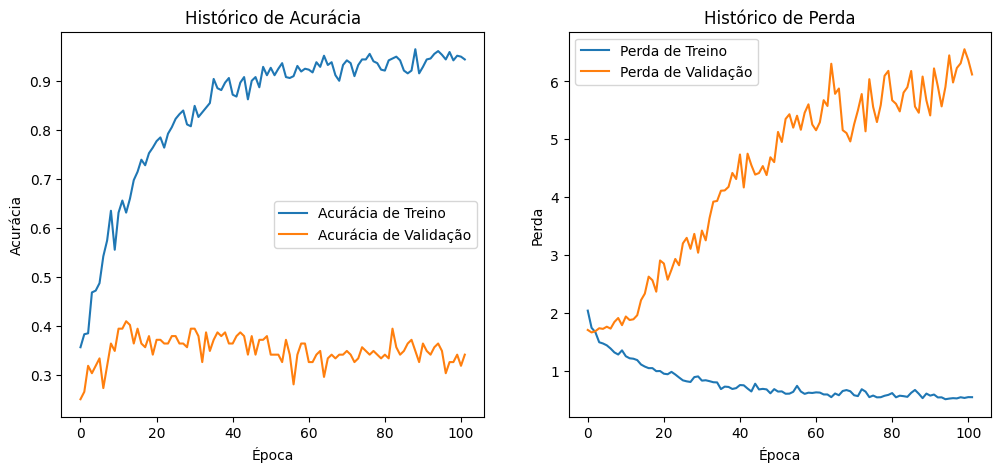


Resultado Final no Conjunto de Teste:
   - Perda (Loss): 1.6525
   - Acurácia (Accuracy): 0.3296
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

      Compra       0.33      0.52      0.40        64
     Lateral       0.32      0.34      0.33        58
       Venda       0.38      0.11      0.16        57

    accuracy                           0.33       179
   macro avg       0.34      0.32      0.30       179
weighted avg       0.34      0.33      0.30       179


Matriz de Confusão:


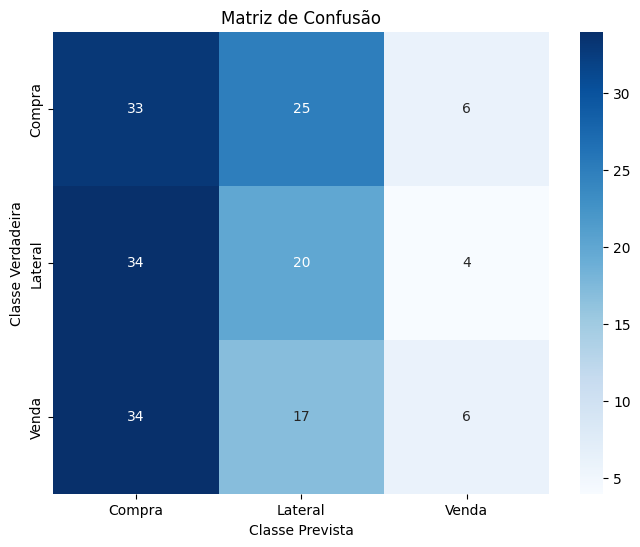

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do TensorFlow e Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf  #pip install tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2


# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

print(f"\n--- SCRIPT DE REORGANIZAÇÃO ORDENADA DO DATASET DE TREINO ---")

# --- ETAPA 1: CARREGAR E SEPARAR X E Y ---
print("\n[ETAPA 1/5] Carregando o dataset e separando Features (X) e Alvo (Y)...")
try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col='datetime', sep=';')
    
    # Identifica as colunas de label e de features
    label_cols = ['label_Compra', 'label_Lateral', 'label_Venda']
    feature_cols = [col for col in df.columns if col not in label_cols]
    
    X_flat = df[feature_cols]
    Y = df[label_cols]
    print(f"Dataset carregado com {len(df)} dias.")
    
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o arquivo: {e}")
    exit()

# --- ETAPA 2: DIVISÃO CRONOLÓGICA EM TREINO E TESTE ---
print("\n[ETAPA 2/5] Dividindo em conjuntos de treino e teste (80/20, cronológico)...")
X_train_orig, X_test, Y_train_orig, Y_test = train_test_split(
    X_flat, Y, test_size=0.2, shuffle=False
)

print(f"Tamanho do conjunto de treino original: {len(X_train_orig)} dias.")
print(f"Tamanho do conjunto de teste: {len(X_test)} dias.")

# --- ETAPA 3: SEPARAR O CONJUNTO DE TREINO POR CLASSE ---
print("\n[ETAPA 3/5] Separando o conjunto de treino por classe...")

# Adiciona a coluna de label original de volta para facilitar a filtragem
Y_train_orig_labels = Y_train_orig.idxmax(axis=1)
X_train_orig['label'] = Y_train_orig_labels

# Cria um DataFrame para cada classe
df_compra = X_train_orig[X_train_orig['label'] == 'label_Compra'].copy()
df_venda = X_train_orig[X_train_orig['label'] == 'label_Venda'].copy()
df_lateral = X_train_orig[X_train_orig['label'] == 'label_Lateral'].copy()

print(f"Amostras de Compra no treino: {len(df_compra)}")
print(f"Amostras de Venda no treino: {len(df_venda)}")
print(f"Amostras de Lateral no treino: {len(df_lateral)}")

# Remove a coluna 'label' temporária
df_compra.drop('label', axis=1, inplace=True)
df_venda.drop('label', axis=1, inplace=True)
df_lateral.drop('label', axis=1, inplace=True)

# --- ETAPA 4: INTERCALAR AS CLASSES PARA CRIAR O NOVO CONJUNTO DE TREINO ---
print("\n[ETAPA 4/5] Intercalando as classes para criar um conjunto de treino ordenado e balanceado...")

# Encontra o número de amostras da classe minoritária
min_samples = min(len(df_compra), len(df_venda), len(df_lateral))
print(f"O novo conjunto de treino terá {min_samples} amostras de cada classe, totalizando {min_samples * 3} dias.")

# Pega apenas o número 'min_samples' de cada DataFrame
df_compra = df_compra.iloc[:min_samples]
df_venda = df_venda.iloc[:min_samples]
df_lateral = df_lateral.iloc[:min_samples]

# Lista para armazenar os DataFrames na ordem correta
ordered_dfs = []
for i in range(min_samples):
    ordered_dfs.append(df_compra.iloc[i:i+1])
    ordered_dfs.append(df_venda.iloc[i:i+1])
    ordered_dfs.append(df_lateral.iloc[i:i+1])

# Concatena todos os pequenos DataFrames em um único DataFrame final
df_train_ordered = pd.concat(ordered_dfs)

# Separa novamente em X e Y
X_train_ordered = df_train_ordered[feature_cols]
Y_train_ordered = pd.get_dummies(df_train_ordered.index.map(Y.idxmax(axis=1))) # Pega os labels correspondentes

print("Conjunto de treino reordenado criado com sucesso.")

#-------------------------------------------------------------------------------
print(f"Tamanho do conjunto de treino: {len(X_train_ordered)} dias")
print(f"Tamanho do conjunto de teste: {len(X_test)} dias")

# --- 3. PADRONIZAÇÃO DAS FEATURES ---
print("\n--- [ETAPA 3/7] Aplicando Padronização (StandardScaler) ---")

# Inicializar o scaler
scaler = StandardScaler()

# Ajustar o scaler APENAS nos dados de treino e transformar ambos
X_train_scaled = scaler.fit_transform(X_train_ordered)
X_test_scaled = scaler.transform(X_test)
print("Features de treino e teste padronizadas.")

# --- 4. CONSTRUIR A ARQUITETURA DO MODELO MLP ---
print("\n--- [ETAPA 4/7] Construindo a Arquitetura do Modelo MLP ---")

# Fatores de regularização L1 e L2 (hiperparâmetros que você pode ajustar)
l1_factor = 0.0001
l2_factor = 0.001

# Construir o modelo MLP
model_mlp = Sequential([
    # Camada de entrada com regularização L1 e L2
    Dense(
        128, 
        activation='relu', 
        input_shape=(X_train_scaled.shape[1],),
        kernel_regularizer=l1_l2(l1=l1_factor, l2=l2_factor) # Aplica L1 e L2
    ),
    # Camada de Dropout para regularização
    Dropout(0.5), # Dropout mais agressivo

    # Camada oculta com regularização L1 e L2
    Dense(
        64, 
        activation='relu',
        kernel_regularizer=l1_l2(l1=l1_factor, l2=l2_factor)
    ),
    # Camada de Dropout
    Dropout(0.5),

    # Camada de saída com função de ativação Softmax
    Dense(3, activation='softmax')
])

# Exibe um resumo da arquitetura do modelo
print("Resumo do Modelo:")
model_mlp.summary()

# --- 5. COMPILAR O MODELO ---
print("\n--- [ETAPA 5/7] Compilando o Modelo ---")

# Compilar o modelo com Otimizador Adam e Perda Categorical Cross-Entropy
model_mlp.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado com sucesso.")

# --- 6. TREINAR O MODELO COM EARLY STOPPING ---
print("\n--- [ETAPA 6/7] Treinando o Modelo ---")

# Callback para parar o treino se a perda na validação não melhorar
# Isso previne o overfitting e encontra a melhor versão do modelo
early_stopping = EarlyStopping(
    monitor='val_loss',       # Monitora a perda no conjunto de validação
    patience=100,              # 15 Número de épocas sem melhora antes de parar
    restore_best_weights=True, # Restaura os pesos da melhor época encontrada
    verbose=1
)

# Treinar o modelo
history = model_mlp.fit(
    X_train_scaled,
    Y_train_ordered,
    epochs=500, # 150 Um número alto, pois o EarlyStopping vai parar quando for a hora
    batch_size=3, # 32
    validation_split=0.2, # Usa 20% do treino para validação interna
    shuffle=False,         #True  Embaralha os dados de treino a cada época
    callbacks=[early_stopping],
    verbose=1
)

# --- 7. AVALIAR O DESEMPENHO FINAL ---
print("\n--- [ETAPA 7/7] Avaliando o Desempenho no Conjunto de Teste ---")

# Plotar o histórico de treinamento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Histórico de Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda de Treino')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Histórico de Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.show()

# Avaliar o modelo no conjunto de teste (dados que ele nunca viu)
test_loss, test_accuracy = model_mlp.evaluate(X_test_scaled, Y_test, verbose=0)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Perda (Loss): {test_loss:.4f}")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")

# Gerar previsões para o conjunto de teste para análise detalhada
Y_pred_probs = model_mlp.predict(X_test_scaled)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
Y_test_classes = np.argmax(Y_test.values, axis=1)

# Mapear os índices das classes para os nomes
class_names = ['Compra', 'Lateral', 'Venda']

# Imprimir o relatório de classificação (precisão, recall, f1-score)
print("\nRelatório de Classificação:")
print(classification_report(Y_test_classes, Y_pred_classes, target_names=class_names))

# Imprimir a Matriz de Confusão
print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test_classes, Y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão')
plt.show()


# Testando Rede Neural Convolucional 1D (CNN)
**Filosofia:** Procura por padrões locais (ex: "engolfo de alta", "três soldados brancos") na sequência de candles, independentemente de onde eles apareçam na janela de 2 horas.

**Passos Específicos:**

1.  **Normalizar os Dados (Achatados PRIMEIRO):**
    *   A normalização deve ser feita nos dados achatados para que o `scaler` aprenda a média e o desvio padrão de cada uma das 264 features.
2.  **Reformatar (Reshape) para 3D:**
    *   Agora, transformamos os dados normalizados de volta para o formato `(dias, timesteps, features_por_timestep)`.
3.  **Construir o Modelo CNN 1D:**
    *   A arquitetura usa camadas `Conv1D` e `MaxPooling1D`.
4.  **Compilar e Treinar:**
5.  **Avaliar:**

# Testando Rede Neural Recorrente (LSTM) 
**Filosofia:** Processa a sequência de 24 candles em ordem, mantendo uma "memória" do que viu nos candles anteriores para influenciar a interpretação dos candles atuais. Ideal para capturar a evolução da tendência.

**Passos Específicos:**

1.  **Normalizar e Reformatar para 3D:**
    *   Os passos são **exatamente os mesmos da CNN**. Você precisa dos dados no formato 3D `(dias, timesteps, features)`.
2.  **Construir o Modelo LSTM:**
    *   A arquitetura usa camadas `LSTM`.
3.  **Compilar e Treinar:**
4.  **Avaliar:**

# RASCUNHO

*****************************
* vale a pena Explorar outros indicadores úteis, como Bandas de Bollinger ou Volume Profile?


* Como definir os limiares para as classes "Compra", "Venda" e "Lateralidade".

* Qauis técnicas de regularização usar?

* Discutir como monitorar a perda (loss) durante o treinamento para diagnosticar problemas.

******************************

*ivar (maior variação de preço do dia das 9h às 16h)
*ivarTreino (maior variação de preço do dia das 9h às 17h)
*tam (tamanho da vela) --------------------------------> valor de fechamento - valor de abertura (indica o tamanho da vela, valor positivo=verde, valor negativo=vermelho)
*tamNor (normalização do tamanho da vela) -------------> tam/ivar 
*tamNorTreino (normalização do tamanho da vela) -------------> tam/ivarTreino 
*#cor (cor da vela) ------------------------------------> tam/|tam|	(+1=verde, -1=vermelho), talves essa variável esteja correlacionada com o tamanho da vela
*var (variação de preço) ------------------------------> preço máximo da vela - preço mínimo da vela  (indica o tamanho da variação entre max e min daquela hora, é o tamanho do pavío + tamanho da vela)
*varNor (normalização da variação de preço) -----------> var/ivar  
*varMax (maior preço de negociação do dia)
*preco (valor de abertura normalizado) ----------------> valor de abertura/varMax 
*vol (volume de ordens)
*ivol (maior volume encontrado no dia, das 9h às 16h)
*vol/ivolTreino (maior volume encontrado no dia, das 9h às 17h)
*volNor (volume normalizado) --------------------------> vol/ivol 
*volNorTreino (volume normalizado) --------------------------> vol/ivolTreino 

-----------VARIÁVEIS TRATADAS PARA TREINO-------------------------------
tamMed (é o tamanho médio entre as velas do dia) ------------> (soma de todas as tamNor)/(quantidade de velas do dia) 	 
volMed (é o volume médio normalizado entre as velas do dia) -> (soma de todos os volNor do dia)/(quantidade de velasdo dia)		

-----------VARIÁVEIS TRATADAS PARA ENTRADA-------------------------------
v1 -> valor de abertura normalizado
v2 -> tamNor (tamanho da vela para aquele horário,  normalizado das 9h às 16h)
v3 -> varNor (variação de preço para aquele horário, normalizado das 9h às 16h)
v4 -> volNor (volume normalizado para aquele horário,  normalizado das 9h às 16h)


-----------------VARIÁVEIS DE ENTRADA------------------
x1 a x5   dados da vela das 9h
x6 a x10  dados da vela das 10h
x11 a x15   dados da vela das 11h
x16 a x20  dados da vela das 12h
x21 a x25   dados da vela das 13h
x26 a x30  dados da vela das 14h
x31 a x35   dados da vela das 15h
x36 a x40   dados da vela das 16h



----------------VARIÁVEIS DE SAIDA--------------
y1 -> compra
y2 -> lateral
y3 -> venda


-----------VARIÁVEIS TRATADAS PARA TREINO (COMPRA)-----------------
VELA VERDE: v2 = +1
VELA GRANDE: tamNorTreino >= [ 50% * tamMed ]
ALTO VOLUME: volNorTreino >= [ 50% * volMed ]

-----------VARIÁVEIS TRATADAS PARA TREINO (LATERAL)-----------------
VELA PEQUENA: tamNorTreino<= [ 50% * tamMed ]
PEQUENO VOLUME: volNor <= [ 50% * volMed ]

-----------VARIÁVEIS TRATADAS PARA TREINO (venda)-----------------
VELA VERMELHA: v2 = -1
VELA GRANDE: tamNorTreino>= [ 50% * tamMed ]
ALTO VOLUME: volNorTreino>= [ 50% * volMed ]